In [1]:
# Board composition measured as at 31 October each year
# Source: FTSE Women Leaders Review Portal
# Note: timing differs from fiscal year-end financials — discuss in methodology

In [2]:
import pandas as pd
import numpy as np
import os

# create folders if they don't exist
for folder in ["data/raw", "data/processed", "outputs/figures", "outputs/tables"]:
    os.makedirs(folder, exist_ok=True)

print("Folders ready")
print("pandas:", pd.__version__)

Folders ready
pandas: 2.2.3


In [3]:
url = "https://ftsewomenleaders.com/company-rankings/"

tables = pd.read_html(url)

print(f"Number of tables found: {len(tables)}")
for i, t in enumerate(tables):
    print(f"\nTable {i}: shape {t.shape}")
    print("Columns:", t.columns.tolist())

Number of tables found: 3

Table 0: shape (95, 8)
Columns: ['Rank', 'Company', 'Supersector', 'Women on Boards', 'Board Size', 'Total Women on Boards', 'Executive Women on Boards', 'Combined Exec.Comm & DRs']

Table 1: shape (165, 8)
Columns: ['Rank', 'Company', 'Supersector', 'Women on Boards', 'Board Size', 'Total Women on Boards', 'Executive Women on Boards', 'Combined Exec.Comm & DRs']

Table 2: shape (48, 8)
Columns: ['Rank', 'Company', 'Supersector', 'Women on Boards', 'Board Size', 'Total Women on Boards', 'Executive Women on Boards', 'Combined Exec.Comm & DRs']


In [4]:
ftse100 = tables[0]

print("Shape:", ftse100.shape)
print("\nData types:")
print(ftse100.dtypes)
print("\nFirst 10 rows:")
ftse100.head(10)

Shape: (95, 8)

Data types:
Rank                          int64
Company                      object
Supersector                  object
Women on Boards              object
Board Size                    int64
Total Women on Boards         int64
Executive Women on Boards     int64
Combined Exec.Comm & DRs     object
dtype: object

First 10 rows:


,Rank,Company,Supersector,Women on Boards,Board Size,Total Women on Boards,Executive Women on Boards,Combined Exec.Comm & DRs
0,1,Burberry Group Plc,Consumer Products & Services,55.6%,9,5,1,56.4%
1,2,Next Plc,Retail,33.3%,12,4,1,53.6%
2,3,Marks & Spencer Group Plc,"Personal Care, Drug & Grocery Stores",66.7%,9,6,1,50.0%
3,4,Phoenix Group Holdings Plc,Insurance,58.3%,12,7,0,49.5%
4,5,Convatec Group Plc,Health Care,55.6%,9,5,1,49.4%
5,6,Diageo Plc,"Food, Beverage & Tobacco",77.8%,9,7,1,49.1%
6,7,Haleon Plc,Health Care,58.3%,12,7,1,47.8%
7,8,Pearson Plc,Media,63.6%,11,7,1,47.6%
8,9,AstraZeneca Plc,Health Care,50.0%,14,7,1,46.8%
9,10,National Grid Plc,Utilities,41.7%,12,5,1,45.7%


In [5]:
print(ftse100.tail(5))
print("\nMissing values per column:")
print(ftse100.isnull().sum())

    Rank                   Company                   Supersector  \
90    91     JD Sports Fashion Plc                        Retail   
91    92        Intertek Group Plc   Industrial Goods & Services   
92    93           Antofagasta Plc               Basic Resources   
93    94         Ashtead Group Plc   Industrial Goods & Services   
94    95  Games Workshop Group Plc  Consumer Products & Services   

   Women on Boards  Board Size  Total Women on Boards  \
90           30.0%          10                      3   
91           30.8%          13                      4   
92           30.8%          13                      4   
93           22.2%           9                      2   
94           28.6%           7                      2   

    Executive Women on Boards Combined Exec.Comm & DRs  
90                          0                    32.6%  
91                          0                    27.7%  
92                          0                    24.7%  
93                  

In [6]:
df = ftse100.copy()

# Convert percentage strings to floats
df["WomenPct"] = df["Women on Boards"].str.replace("%", "", regex=False).astype(float)
df["ExecCommPct"] = df["Combined Exec.Comm & DRs"].str.replace("%", "", regex=False).astype(float)

# Rename to clean column names
df = df.rename(columns={
    "Board Size": "BoardSize",
    "Total Women on Boards": "TotalWomen",
    "Executive Women on Boards": "ExecWomen"
})

# Tag the year — this is the 2026 report, reporting on 2025 data
df["Year"] = 2025

# Standardised company key for later merging
df["CompanyKey"] = (df["Company"]
                    .str.upper()
                    .str.replace(r"\b(PLC|LIMITED|LTD|GROUP|HOLDINGS)\b", "", regex=True)
                    .str.replace(r"[^A-Z0-9 ]", "", regex=True)
                    .str.replace(r"\s+", " ", regex=True)
                    .str.strip())

keep = ["CompanyKey", "Company", "Year", "Supersector", "WomenPct", 
        "BoardSize", "TotalWomen", "ExecWomen", "ExecCommPct"]
df_clean = df[keep]

print(df_clean.dtypes)
print()
df_clean.head(10)

CompanyKey      object
Company         object
Year             int64
Supersector     object
WomenPct       float64
BoardSize        int64
TotalWomen       int64
ExecWomen        int64
ExecCommPct    float64
dtype: object



,CompanyKey,Company,Year,Supersector,WomenPct,BoardSize,TotalWomen,ExecWomen,ExecCommPct
0,BURBERRY,Burberry Group Plc,2025,Consumer Products & Services,55.6,9,5,1,56.4
1,NEXT,Next Plc,2025,Retail,33.3,12,4,1,53.6
2,MARKS SPENCER,Marks & Spencer Group Plc,2025,"Personal Care, Drug & Grocery Stores",66.7,9,6,1,50.0
3,PHOENIX,Phoenix Group Holdings Plc,2025,Insurance,58.3,12,7,0,49.5
4,CONVATEC,Convatec Group Plc,2025,Health Care,55.6,9,5,1,49.4
5,DIAGEO,Diageo Plc,2025,"Food, Beverage & Tobacco",77.8,9,7,1,49.1
6,HALEON,Haleon Plc,2025,Health Care,58.3,12,7,1,47.8
7,PEARSON,Pearson Plc,2025,Media,63.6,11,7,1,47.6
8,ASTRAZENECA,AstraZeneca Plc,2025,Health Care,50.0,14,7,1,46.8
9,NATIONAL GRID,National Grid Plc,2025,Utilities,41.7,12,5,1,45.7


In [7]:
print(df_clean["WomenPct"].describe())
print("\nFirms below 30% (critical mass threshold):", (df_clean["WomenPct"] < 30).sum())
print("Firms at or above 30%:", (df_clean["WomenPct"] >= 30).sum())
print("\nBoard size range:", df_clean["BoardSize"].min(), "to", df_clean["BoardSize"].max())

count    95.000000
mean     44.510526
std       9.582603
min      22.200000
25%      39.250000
50%      44.400000
75%      50.000000
max      77.800000
Name: WomenPct, dtype: float64

Firms below 30% (critical mass threshold): 4
Firms at or above 30%: 91

Board size range: 7 to 18


In [8]:
df_clean.to_csv("data/raw/board_2025_clean.csv", index=False)
print(f"Saved {len(df_clean)} rows")

Saved 95 rows


In [9]:
import requests
import os

os.makedirs("data/raw/ftse_reports", exist_ok=True)

pdfs = {
    "ftse_wl_2024.pdf": "https://ftsewomenleaders.com/wp-content/uploads/2025/03/ftse-report-master-2025-online-v3.pdf",
    "ftse_wl_2023.pdf": "https://ftsewomenleaders.com/wp-content/uploads/2024/04/ftse-women-leaders-report-final-april-2024.pdf",
    "ftse_wl_2022.pdf": "https://ftsewomenleaders.com/wp-content/uploads/2023/03/ftse-women-leaders-review-report-2022-v2.pdf",
    "ftse_wl_2021.pdf": "https://ftsewomenleaders.com/wp-content/uploads/2022/03/2021_FTSE-Women-Leaders-Review_Final-Report_WA.pdf",
    "ftse_wl_2020.pdf": "https://ftsewomenleaders.com/wp-content/uploads/2021/03/Hampton-Alexander-Review-Report-2020_web.pdf",
    "ftse_wl_2019.pdf": "https://ftsewomenleaders.com/wp-content/uploads/2019/11/HA-Review-Report-2019.pdf",
}

for filename, url in pdfs.items():
    path = f"data/raw/ftse_reports/{filename}"
    if os.path.exists(path):
        print(f"Already have {filename}")
        continue
    r = requests.get(url, timeout=60)
    with open(path, "wb") as f:
        f.write(r.content)
    print(f"Downloaded {filename} ({len(r.content)/1e6:.1f} MB)")

Already have ftse_wl_2024.pdf
Already have ftse_wl_2023.pdf
Already have ftse_wl_2022.pdf
Already have ftse_wl_2021.pdf
Already have ftse_wl_2020.pdf
Already have ftse_wl_2019.pdf


In [10]:
!pip install pdfplumber
import pdfplumber

with pdfplumber.open("data/raw/ftse_reports/ftse_wl_2024.pdf") as pdf:
    print("Total pages:", len(pdf.pages))
    for i, page in enumerate(pdf.pages):
        t = page.extract_text() or ""
        if "FTSE 100 Rankings" in t:
            print(f"PDF page index {i} contains FTSE 100 Rankings")

Defaulting to user installation because normal site-packages is not writeable
Total pages: 72
PDF page index 41 contains FTSE 100 Rankings
PDF page index 42 contains FTSE 100 Rankings
PDF page index 43 contains FTSE 100 Rankings
PDF page index 44 contains FTSE 100 Rankings


In [15]:
import pdfplumber
import re
import pandas as pd

ROW_RE = re.compile(r"^(\d{1,3})\s+(.+?)\s+(\d{1,3}\.\d)%\s+(.*?)\s*(\d{1,3}\.\d)%$")

def parse_column(text, year, rows):
    lines = [l.strip() for l in text.split("\n") if l.strip()]
    i = 0
    while i < len(lines):
        if re.match(r"^\d{1,3}\s", lines[i]):
            matched = False
            for span in (1, 2, 3):
                if i + span > len(lines):
                    break
                candidate = " ".join(lines[i:i+span])
                m = ROW_RE.match(candidate)
                if m:
                    rank, name_sector, women_pct, roles, exco_pct = m.groups()
                    rows.append({"Year": year, "Rank": int(rank), "NameSector": name_sector.strip(), "WomenPct": float(women_pct), "KeyRoles": roles.strip(), "ExCoPct": float(exco_pct)})
                    i += span
                    matched = True
                    break
            if not matched:
                i += 1
        else:
            i += 1

def extract_ftse100(pdf_path, year, page_range):
    rows = []
    with pdfplumber.open(pdf_path) as pdf:
        for page_num in page_range:
            page = pdf.pages[page_num]
            mid = page.width / 2
            parse_column(page.crop((0, 0, mid, page.height)).extract_text() or "", year, rows)
            parse_column(page.crop((mid, 0, page.width, page.height)).extract_text() or "", year, rows)
    return pd.DataFrame(rows).sort_values("Rank").reset_index(drop=True)

df_2024 = extract_ftse100("data/raw/ftse_reports/ftse_wl_2024.pdf", 2024, range(41, 45))
print(f"Extracted {len(df_2024)} rows")
print(f"Rank range: {df_2024['Rank'].min()} to {df_2024['Rank'].max()}")
print(f"Duplicates: {df_2024['Rank'].duplicated().sum()}")
missing = sorted(set(range(1, 97)) - set(df_2024['Rank']))
print(f"Missing ranks: {missing}")
df_2024.head(15)

Extracted 96 rows
Rank range: 1 to 96
Duplicates: 0
Missing ranks: []


,Year,Rank,NameSector,WomenPct,KeyRoles,ExCoPct
0,2024,1,Marks & Spencer Group Plc,60.0,SID CFO,54.0
1,2024,2,Pearson Plc Media,60.0,CFO,51.5
2,2024,3,Next Plc Retail,33.3,,50.5
3,2024,4,"Diageo Plc Food, Beverage & Tobacco",70.0,SID CEO,49.5
4,2024,5,AstraZeneca Plc Health Care,42.9,CFO,48.9
5,2024,6,Phoenix Group Holdings Plc Insurance,41.7,SID CFO,47.5
6,2024,7,National Grid Plc Utilities,36.4,Chair,47.2
7,2024,8,Haleon Plc Health Care,54.5,CFO,46.8
8,2024,9,NatWest Group Plc Banks,50.0,CFO,46.8
9,2024,10,BP Plc Energy,54.5,SID CFO,46.5


In [16]:
SECTORS = [
    "Personal Care, Drug & Grocery Stores", "Industrial Goods & Services",
    "Consumer Products & Services", "Food, Beverage & Tobacco",
    "Telecommunications", "Financial Services", "Travel & Leisure",
    "Basic Resources", "Health Care", "Real Estate", "Technology",
    "Insurance", "Utilities", "Chemicals", "Energy", "Media",
    "Retail", "Banks", "Automobiles & Parts", "Construction & Materials"
]

def split_name_sector(text):
    for sector in sorted(SECTORS, key=len, reverse=True):
        if text.endswith(sector):
            return text[:-len(sector)].strip(), sector
    return text.strip(), None

df_2024[["Company", "Sector"]] = df_2024["NameSector"].apply(lambda x: pd.Series(split_name_sector(x)))

print("Rows with no sector matched:", df_2024["Sector"].isna().sum())
print()
print(df_2024[df_2024["Sector"].isna()][["Rank", "NameSector"]])

Rows with no sector matched: 11

    Rank                   NameSector
0      1    Marks & Spencer Group Plc
27    28              J Sainsbury Plc
28    29     Barratt Developments Plc
29    30                 Unilever Plc
44    45            Compass Group Plc
55    56                Persimmon Plc
57    58  Berkeley Group Holdings Plc
70    71                    Tesco Plc
81    82  Reckitt Benckiser Group Plc
86    87            Taylor Wimpey Plc
91    92     Games Workshop Group Plc


In [17]:
def make_key(s):
    return (s.str.upper()
             .str.replace(r"\b(PLC|LIMITED|LTD|GROUP|HOLDINGS|SA|AG|S\.A\.)\b", "", regex=True)
             .str.replace(r"[^A-Z0-9 ]", "", regex=True)
             .str.replace(r"\s+", " ", regex=True)
             .str.strip())

df_2024["CompanyKey"] = make_key(df_2024["Company"])

df_2024[["Rank", "Company", "CompanyKey", "Sector", "WomenPct"]].head(10)

,Rank,Company,CompanyKey,Sector,WomenPct
0,1,Marks & Spencer Group Plc,MARKS SPENCER,None,60.0
1,2,Pearson Plc,PEARSON,Media,60.0
2,3,Next Plc,NEXT,Retail,33.3
3,4,Diageo Plc,DIAGEO,"Food, Beverage & Tobacco",70.0
4,5,AstraZeneca Plc,ASTRAZENECA,Health Care,42.9
5,6,Phoenix Group Holdings Plc,PHOENIX,Insurance,41.7
6,7,National Grid Plc,NATIONAL GRID,Utilities,36.4
7,8,Haleon Plc,HALEON,Health Care,54.5
8,9,NatWest Group Plc,NATWEST,Banks,50.0
9,10,BP Plc,BP,Energy,54.5


In [18]:
df_2024.to_csv("data/raw/board_2024_clean.csv", index=False)
print(f"Saved {len(df_2024)} rows")

Saved 96 rows


In [20]:
for year in [2023, 2022, 2021, 2020, 2019]:
    path = f"data/raw/ftse_reports/ftse_wl_{year}.pdf"
    try:
        with pdfplumber.open(path) as pdf:
            pages = [i for i, p in enumerate(pdf.pages) if "FTSE 100 Rankings" in (p.extract_text() or "")]
            print(f"{year}: {len(pdf.pages)} pages total, FTSE 100 Rankings on {pages}")
    except Exception as e:
        print(f"{year}: ERROR — {e}")

2023: 82 pages total, FTSE 100 Rankings on [2, 6]
2022: 82 pages total, FTSE 100 Rankings on [2, 49, 51]
2021: 78 pages total, FTSE 100 Rankings on [2, 47, 49]
2020: 84 pages total, FTSE 100 Rankings on [2, 53, 55, 56]
2019: 80 pages total, FTSE 100 Rankings on [2, 35, 49, 51, 52]


In [21]:
import re

pat = re.compile(r"^\d{1,3}\s+.+?\s+\d{1,3}\.\d%")

for year in [2023, 2022, 2021, 2020, 2019]:
    path = f"data/raw/ftse_reports/ftse_wl_{year}.pdf"
    with pdfplumber.open(path) as pdf:
        hits = []
        for i, p in enumerate(pdf.pages):
            lines = (p.extract_text() or "").split("\n")
            n = sum(1 for l in lines if pat.match(l.strip()))
            if n >= 5:
                hits.append((i, n))
    print(f"{year}: {hits}")

2023: [(11, 8), (13, 5), (28, 6), (36, 9), (40, 10), (49, 25), (50, 26), (51, 27), (52, 17), (53, 27), (54, 25), (55, 25), (56, 26), (57, 21), (58, 22), (59, 13), (61, 10), (62, 5), (64, 12), (65, 22), (66, 23), (67, 25), (68, 30), (69, 21), (70, 26), (71, 20), (72, 19), (73, 29), (74, 26), (75, 34), (76, 25)]
2022: [(11, 9), (19, 7), (30, 10), (49, 25), (50, 26), (51, 25), (52, 16), (53, 25), (54, 25), (55, 25), (56, 24), (57, 24), (58, 21), (59, 15), (61, 5), (62, 7), (65, 24), (66, 23), (67, 21), (68, 28), (69, 18), (70, 21), (71, 20), (72, 23), (73, 31), (74, 29), (75, 30), (76, 20)]
2021: [(15, 6), (19, 5), (21, 6), (30, 6), (47, 23), (48, 26), (49, 26), (50, 19), (51, 26), (52, 26), (53, 23), (54, 23), (55, 24), (56, 20), (57, 22), (58, 6), (59, 6), (61, 18), (63, 20), (64, 24), (65, 18), (66, 25), (67, 27), (68, 26), (69, 24), (70, 31), (71, 27), (72, 22), (73, 21)]
2020: [(15, 6), (30, 6), (53, 23), (54, 26), (55, 26), (56, 21), (57, 14), (58, 22), (59, 11), (60, 26), (61, 25),

In [23]:
for year in [2023, 2022, 2021, 2020, 2019]:
    path = f"data/raw/ftse_reports/ftse_wl_{year}.pdf"
    print(f"\n{'='*20} {year} {'='*20}")
    with pdfplumber.open(path) as pdf:
        for i in range(40, min(len(pdf.pages), 82)):
            text = pdf.pages[i].extract_text() or ""
            first_lines = " | ".join(text.split("\n")[:3])
            if "FTSE" in first_lines or "Appendix" in first_lines or "Ranking" in first_lines:
                print(f"p{i}: {first_lines[:110]}")


==================== 2023 ====================
p40: Document under Embargo until one minute past midnight (00.01pm) on the 27th February 2024 Document under Embar
p41: Document under Embargo until one minute past midnight (00.01pm) on the 27th February 2024 Document under Embar
p45: Document under Embargo until one minute past midnight (00.01pm) on the 27th February 2024 Document under Embar
p47: Document under Embargo until one minute past midnight (00.01pm) on the 27th February 2024 Document under Embar
p48: Document under Embargo until one minute past midnight (00.01pm) on the 27th February 2024 Document under Embar
p49: Document under Embargo until one minute past midnight (00.01pm) on the 27th February 2024 Document under Embar
p51: Document under Embargo until one minute past midnight (00.01pm) on the 27th February 2024 Document under Embar
p53: Document under Embargo until one minute past midnight (00.01pm) on the 27th February 2024 Document under Embar
p55: Document under Emba

In [25]:
with pdfplumber.open("data/raw/ftse_reports/ftse_wl_2023.pdf") as pdf:
    for i in [49, 50, 51]:
        page = pdf.pages[i]
        mid = page.width / 2
        left = page.crop((0, 0, mid, page.height)).extract_text() or ""
        print(f"\n{'='*25} PAGE {i} LEFT COLUMN {'='*25}")
        print(left[:800])


========================= PAGE 49 LEFT COLUMN =========================
Document under Embargo until one minute pas
5. Appendix C FTSE 100
Rankings 2023 Women on Boards and in Lead
Women on Boards data as at 11th January 2024, Leadership da
(Excludes 3 Investment Trusts)
At or above 33% and on
At or above 40% Target
track to meet 40% Target
Wom
Rank28 Company Sector
on Bo
Consumer Products
1 Burberry Group Plc 50
& Services
Personal Care, Drug
2 Marks & Spencer Group Plc 54.
& Grocery Stores
3 Next Plc Retail 36.
4 National Grid Plc Utilities 41.
5 Lloyds Banking Group Plc Banks 45.
6 Pearson Plc Media 54.
7 AstraZeneca Plc Health Care 46.
Food, Beverage
8 Diageo Plc 70
& Tobacco
9 Haleon Plc Health Care 45.
10 BP Plc Energy 50
50
11 Rightmove Plc Real Estate 57.
12 Phoenix Group Holdings Plc Insurance 38.
Personal Care, Drug
13 J Sainsbury Plc 44.
& Grocery S

========================= PAGE 50 LEFT COLUMN =========================
Document under Embargo until one minute pas
Wom
Rank 

In [27]:
import pdfplumber
import re
import pandas as pd

ROW_2023 = re.compile(r"^(\d{1,3})\s+(.+?)\s+(\d{1,3}(?:\.\d)?)%?\s*$")

def parse_col_2023(text, year, rows):
    lines = [l.strip() for l in text.split("\n") if l.strip()]
    for idx, line in enumerate(lines):
        m = ROW_2023.match(line)
        if not m:
            continue
        rank, body, pct = m.groups()
        rank = int(rank)
        if not (1 <= rank <= 110):
            continue
        val = float(pct)
        if not (0 <= val <= 100):
            continue
        rows.append({"Year": year, "Rank": rank, "NameSector": body.strip(), "WomenPct": val})

def extract_2023style(pdf_path, year, page_range, split=0.55):
    rows = []
    with pdfplumber.open(pdf_path) as pdf:
        for pn in page_range:
            page = pdf.pages[pn]
            mid = page.width * split
            parse_col_2023(page.crop((0, 0, mid, page.height)).extract_text() or "", year, rows)
            parse_col_2023(page.crop((mid, 0, page.width, page.height)).extract_text() or "", year, rows)
    df = pd.DataFrame(rows)
    return df.drop_duplicates(subset=["Rank"]).sort_values("Rank").reset_index(drop=True) if len(df) else df

df_2023 = extract_2023style("data/raw/ftse_reports/ftse_wl_2023.pdf", 2023, range(49, 54))
print(f"Rows: {len(df_2023)}")
if len(df_2023):
    print(f"Ranks {df_2023['Rank'].min()}-{df_2023['Rank'].max()}, missing: {sorted(set(range(1,98)) - set(df_2023['Rank']))}")

Rows: 97
Ranks 1-97, missing: []


In [28]:
print(df_2023.head(15))
print()
print(df_2023["WomenPct"].describe())

    Year  Rank                            NameSector  WomenPct
0   2023     1                    Burberry Group Plc      50.0
1   2023     2             Marks & Spencer Group Plc      54.5
2   2023     3                       Next Plc Retail      36.4
3   2023     4           National Grid Plc Utilities      41.7
4   2023     5        Lloyds Banking Group Plc Banks      45.5
5   2023     6                     Pearson Plc Media      54.5
6   2023     7           AstraZeneca Plc Health Care      46.2
7   2023     8                            Diageo Plc      70.0
8   2023     9                Haleon Plc Health Care      45.5
9   2023    10                         BP Plc Energy      50.0
10  2023    11             Rightmove Plc Real Estate      57.1
11  2023    12  Phoenix Group Holdings Plc Insurance      38.5
12  2023    13                       J Sainsbury Plc      44.4
13  2023    14                    Financial Services      41.7
14  2023    15                 Beazley Plc Insurance   

In [29]:
for year, pages in {2022: range(49, 54), 2021: range(47, 52), 2020: range(53, 58), 2019: range(63, 68)}.items():
    try:
        df = extract_2023style(f"data/raw/ftse_reports/ftse_wl_{year}.pdf", year, pages)
        if len(df) == 0:
            print(f"{year}: 0 rows")
            continue
        print(f"{year}: {len(df)} rows, ranks {df['Rank'].min()}-{df['Rank'].max()}, mean {df['WomenPct'].mean():.1f}%")
        globals()[f"df_{year}"] = df
    except Exception as e:
        print(f"{year}: FAILED — {e}")

2022: 97 rows, ranks 1-97, mean 40.7%
2021: 98 rows, ranks 1-98, mean 39.4%
2020: 97 rows, ranks 1-100, mean 30.0%
2019: 1 rows, ranks 100-100, mean 61.3%


In [30]:
with pdfplumber.open("data/raw/ftse_reports/ftse_wl_2019.pdf") as pdf:
    for i in [63, 64, 65]:
        page = pdf.pages[i]
        print(f"\n{'='*25} PAGE {i} (full width) {'='*25}")
        print((page.extract_text() or "")[:900])


========================= PAGE 63 (full width) =========================
Appendix E
FTSE 350 Sector Analysis
Women on Boards data as at October 2019, Leadership data as at 30th June 2019
Sector : Investment Trusts
FTSE Women Combined
Rank Company Sector Detail
List on Boards Exec.Comm & DRs
1 Law Debenture Corporation Closed End Investments 250 29% 44.9%
2 Scottish Investment Trust Plc Closed End Investments 250 33% 44.4%
3 Syncona LTD Closed End Investments 250 25% 43.8%
4 Caledonia Investments Plc Closed End Investments 250 22% 28.6%
5 BBGI Sicav SA Closed End Investments 250 33% 25%
Average 31.7% 40.1%
Sector Average
Sector : Personal Goods
FTSE Women Combined
Rank Company Sector Detail
List on Boards Exec.Comm & DRs
1 Burberry Group Plc Personal Goods 100 50% 61.3%
2 Unilever Plc Personal Goods 100 38% 33.8%
3 Games Workshop Group Plc Leisure Goods 250 50% 27.3%
4 PZ Cussons Plc Personal Goods 250 43% 25%
New Entry
5 Watches Of Switzerland Group Plc Perso

========================

In [31]:
print(df_2023.head(8))
print()
print("Marks & Spencer:", df_2023[df_2023["NameSector"].str.contains("Marks", na=False)]["WomenPct"].values)

   Year  Rank                      NameSector  WomenPct
0  2023     1              Burberry Group Plc      50.0
1  2023     2       Marks & Spencer Group Plc      54.5
2  2023     3                 Next Plc Retail      36.4
3  2023     4     National Grid Plc Utilities      41.7
4  2023     5  Lloyds Banking Group Plc Banks      45.5
5  2023     6               Pearson Plc Media      54.5
6  2023     7     AstraZeneca Plc Health Care      46.2
7  2023     8                      Diageo Plc      70.0

Marks & Spencer: [54.5]


In [32]:
print(df_2023[df_2023["NameSector"].str.contains("Marks", na=False)][["Rank", "NameSector", "WomenPct"]])

   Rank                 NameSector  WomenPct
1     2  Marks & Spencer Group Plc      54.5


In [33]:
with pdfplumber.open("data/raw/ftse_reports/ftse_wl_2019.pdf") as pdf:
    for i in [63, 64, 65]:
        page = pdf.pages[i]
        print(f"\n{'='*25} PAGE {i} {'='*25}")
        print((page.extract_text() or "")[:900])


========================= PAGE 63 =========================
Appendix E
FTSE 350 Sector Analysis
Women on Boards data as at October 2019, Leadership data as at 30th June 2019
Sector : Investment Trusts
FTSE Women Combined
Rank Company Sector Detail
List on Boards Exec.Comm & DRs
1 Law Debenture Corporation Closed End Investments 250 29% 44.9%
2 Scottish Investment Trust Plc Closed End Investments 250 33% 44.4%
3 Syncona LTD Closed End Investments 250 25% 43.8%
4 Caledonia Investments Plc Closed End Investments 250 22% 28.6%
5 BBGI Sicav SA Closed End Investments 250 33% 25%
Average 31.7% 40.1%
Sector Average
Sector : Personal Goods
FTSE Women Combined
Rank Company Sector Detail
List on Boards Exec.Comm & DRs
1 Burberry Group Plc Personal Goods 100 50% 61.3%
2 Unilever Plc Personal Goods 100 38% 33.8%
3 Games Workshop Group Plc Leisure Goods 250 50% 27.3%
4 PZ Cussons Plc Personal Goods 250 43% 25%
New Entry
5 Watches Of Switzerland Group Plc Perso

========================= PAGE 64 ===

In [34]:
print("Missing 2020 ranks:", sorted(set(range(1, 101)) - set(df_2020["Rank"])))
print(df_2020["WomenPct"].describe())

Missing 2020 ranks: [39, 68, 76]
count    97.000000
mean     30.040206
std       7.944215
min      10.600000
25%      24.300000
50%      30.200000
75%      34.500000
max      53.800000
Name: WomenPct, dtype: float64


In [35]:
import re

ROW_2019 = re.compile(r"^(\d{1,3})\s+(.+?)\s+(100|250)\s+(\d{1,3})%\s+([\d.]+)%\s*$")

def extract_2019(pdf_path, year=2019):
    rows = []
    with pdfplumber.open(pdf_path) as pdf:
        for pn in range(len(pdf.pages)):
            text = pdf.pages[pn].extract_text() or ""
            for line in text.split("\n"):
                m = ROW_2019.match(line.strip())
                if m:
                    rank, body, ftse_list, women, exco = m.groups()
                    rows.append({
                        "Year": year,
                        "SectorRank": int(rank),
                        "NameSector": body.strip(),
                        "FTSEList": int(ftse_list),
                        "WomenPct": float(women),
                        "ExCoPct": float(exco)
                    })
    return pd.DataFrame(rows)

raw_2019 = extract_2019("data/raw/ftse_reports/ftse_wl_2019.pdf")
print(f"Total rows parsed: {len(raw_2019)}")
print(raw_2019["FTSEList"].value_counts())

df_2019 = raw_2019[raw_2019["FTSEList"] == 100].drop_duplicates(subset=["NameSector"]).reset_index(drop=True)
print(f"\nFTSE 100 firms: {len(df_2019)}")
print(f"Mean WomenPct: {df_2019['WomenPct'].mean():.1f}%")
df_2019.head(15)

Total rows parsed: 283
FTSEList
250    184
100     99
Name: count, dtype: int64

FTSE 100 firms: 99
Mean WomenPct: 32.4%


,Year,SectorRank,NameSector,FTSEList,WomenPct,ExCoPct
0,2019,1,Burberry Group Plc Personal Goods,100,50.0,61.3
1,2019,2,Unilever Plc Personal Goods,100,38.0,33.8
2,2019,1,Next Plc Diversified Retailers,100,44.0,53.9
3,2019,9,JD Sports Fashion Plc Apparel Retailers,100,29.0,30.0
4,2019,10,Kingfisher Plc Home Improvement Retailers,100,44.0,29.8
5,2019,14,Just Eat Plc Consumer Services,100,30.0,23.1
6,2019,2,Astrazeneca Plc Pharmaceuticals,100,33.0,40.3
7,2019,3,GlaxoSmithKline Plc Pharmaceuticals,100,45.0,38.1
8,2019,4,Hikma Pharmaceuticals Plc Pharmaceuticals,100,27.0,23.2
9,2019,1,WM Morrison Supermarkets Plc Food Retailers an...,100,22.0,41.4


In [36]:
def clean_company_2019(text):
    m = re.match(r"^(.+?(?:Plc|PLC|Ltd|LTD|LIMITED|SA|S\.A\.|AG))\b", text)
    return m.group(1).strip() if m else text.strip()

df_2019["Company"] = df_2019["NameSector"].apply(clean_company_2019)
df_2019["CompanyKey"] = make_key(df_2019["Company"])
print(df_2019[["Company", "CompanyKey", "WomenPct"]].head(15))

                         Company                CompanyKey  WomenPct
0             Burberry Group Plc                  BURBERRY      50.0
1                   Unilever Plc                  UNILEVER      38.0
2                       Next Plc                      NEXT      44.0
3          JD Sports Fashion Plc         JD SPORTS FASHION      29.0
4                 Kingfisher Plc                KINGFISHER      44.0
5                   Just Eat Plc                  JUST EAT      30.0
6                Astrazeneca Plc               ASTRAZENECA      33.0
7            GlaxoSmithKline Plc           GLAXOSMITHKLINE      45.0
8      Hikma Pharmaceuticals Plc     HIKMA PHARMACEUTICALS      27.0
9   WM Morrison Supermarkets Plc  WM MORRISON SUPERMARKETS      22.0
10   Sainsburys Supermarkets Ltd   SAINSBURYS SUPERMARKETS      30.0
11               Ocado Group Plc                     OCADO      25.0
12                     Tesco Plc                     TESCO      31.0
13                       ITV Plc  

In [37]:
print("FTSE 100 firms extracted:", len(df_2019))
print("Mean WomenPct:", round(df_2019["WomenPct"].mean(), 1))

FTSE 100 firms extracted: 99
Mean WomenPct: 32.4


In [38]:
import pandas as pd

# 2025 from the web scrape — rename to match
df_2025 = pd.read_csv("data/raw/board_2025_clean.csv")
df_2025 = df_2025.rename(columns={"CompanyKey": "CompanyKey"})[["CompanyKey", "Company", "Year", "WomenPct"]]

frames = [df_2025]

for year in [2024, 2023, 2022, 2021, 2020]:
    df = globals()[f"df_{year}"].copy()
    if "Company" not in df.columns:
        df[["Company", "Sector"]] = df["NameSector"].apply(lambda x: pd.Series(split_name_sector(x)))
    if "CompanyKey" not in df.columns:
        df["CompanyKey"] = make_key(df["Company"])
    frames.append(df[["CompanyKey", "Company", "Year", "WomenPct"]])

frames.append(df_2019[["CompanyKey", "Company", "Year", "WomenPct"]])

board_panel = pd.concat(frames, ignore_index=True)
board_panel = board_panel.dropna(subset=["CompanyKey", "WomenPct"])
board_panel = board_panel[board_panel["CompanyKey"] != ""]
board_panel = board_panel.drop_duplicates(subset=["CompanyKey", "Year"])

print(f"Total observations: {len(board_panel)}")
print(f"Unique firms: {board_panel['CompanyKey'].nunique()}")
print()
print(board_panel.groupby("Year").agg(n=("WomenPct", "size"), mean_pct=("WomenPct", "mean")).round(1))

Total observations: 660
Unique firms: 196

       n  mean_pct
Year              
2019  99      32.4
2020  94      30.0
2021  94      39.3
2022  93      40.6
2023  93      42.8
2024  92      44.8
2025  95      44.5


In [39]:
board_panel.to_csv("data/processed/board_diversity_panel.csv", index=False)
print("Saved.")

Saved.


In [40]:
counts = board_panel.groupby("CompanyKey")["Year"].count().sort_values()
print("Firms appearing in only 1 year:", (counts == 1).sum())
print("Firms appearing in all 7 years:", (counts == 7).sum())
print()
print("Singletons (likely matching failures):")
print(counts[counts == 1].index.tolist()[:60])

Firms appearing in only 1 year: 80
Firms appearing in all 7 years: 28

Singletons (likely matching failures):
['10 GLAXOSMITHKLINE', '4 2', 'AIRLINES', 'ADMIRAL NONLIFE', 'ASHTEAD SUPPORT SERVICES', 'ASSOCIATED BRITISH FOODS FOOD PRODUCERS', 'ANTOFAGASTA MINING', 'ANGLO AMERICAN MINING', 'BAE SYSTEMS AEROSPACE DEFENSE', 'BARRATT REDROW', 'BHP', 'BHP BILLITON', 'AVIVA LIFE', 'BABCOCK INTERNATIONAL', 'BM EUROPEAN VALUE RETAIL GENERAL RETAILERS', 'BHP MINING', 'BT PLC29', 'COCACOLA EUROPACIFIC PARTNERS', 'COCACOLA HBC BEVERAGES', 'DCC SUPPORT SERVICES', 'DIAGEO BEVERAGES', 'COCACOLA HBC AG', 'BUNZL GENERAL INDUSTRIALS', 'CARNIVAL', 'BRITISH AMERICAN TOBACCO TOBACCO', 'BT PLC33', 'BURBERRY PERSONAL GOODS', 'BRITISH LAND CO', 'BP OIL GAS INDUSTRY', 'EVRAZ MINING', 'ELECTROCOMPONENTS', 'DS SMITH GENERAL INDUSTRIALS', 'INTERNATIONAL CONSOLIDATED AIRLINES SA', 'INTERTEK SUPPORT SERVICES', 'JD SPORTS FASHION GENERAL RETAILERS', 'KINGFISHER GENERAL RETAILERS', 'JUST EAT', 'JUST EAT TAKEAWAYCOM N

In [43]:
import re

def make_key(s):
    s = s.astype(str)
    s = s.str.replace(r"\d+", "", regex=True)                     # strip footnote digits
    s = s.str.upper()
    s = s.str.replace(r"[^A-Z ]", " ", regex=True)                # punctuation to space
    s = s.str.replace(r"\b(PLC|LIMITED|LTD|GROUP|HOLDINGS|COMPANY|CO|SA|AG|NV|SE|INTERNATIONAL|THE)\b", " ", regex=True)
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    return s

In [44]:
SECTOR_WORDS = [
    "PERSONAL GOODS","GENERAL RETAILERS","FOOD PRODUCERS","SUPPORT SERVICES","MINING",
    "BEVERAGES","TOBACCO","GENERAL INDUSTRIALS","AEROSPACE DEFENSE","OIL GAS INDUSTRY",
    "LIFE","NONLIFE","CASINOS AND GAMBLING","GOODS HOME","LIFE INSURANCE","PHARMACEUTICALS",
    "FOOD RETAILERS AND WHOLESALERS","DIVERSIFIED RETAILERS","APPAREL RETAILERS",
    "SPECIALTY RETAILERS","HOME IMPROVEMENT RETAILERS","CONSUMER SERVICES","PUBLISHING",
    "RADIO AND TV BROADCASTERS","MEDIA AGENCIES","ENTERTAINMENT","CLOSED END INVESTMENTS",
    "LEISURE GOODS","CONSUMER DIGITAL SERVICES","ENERGY METALS","BANKS","INSURANCE",
    "UTILITIES","CHEMICALS","REAL ESTATE","TECHNOLOGY","MEDIA","RETAIL","ENERGY",
    "HEALTH CARE","FINANCIAL SERVICES","TRAVEL LEISURE","BASIC RESOURCES"
]

def strip_sector(key):
    changed = True
    while changed:
        changed = False
        for w in sorted(SECTOR_WORDS, key=len, reverse=True):
            if key.endswith(" " + w) or key == w:
                key = key[: -len(w)].strip()
                changed = True
    return key.strip()

board_panel["CompanyKey"] = make_key(board_panel["Company"]).apply(strip_sector)
print("Unique firms now:", board_panel["CompanyKey"].nunique())

Unique firms now: 145


In [45]:
RENAMES = {
    "GLAXOSMITHKLINE": "GSK",
    "ROYAL DUTCH SHELL": "SHELL",
    "ROYAL BANK OF SCOTLAND": "NATWEST",
    "ELECTROCOMPONENTS": "RS",
    "BHP BILLITON": "BHP",
    "COCACOLA HBC": "COCACOLA HBC",
    "JUST EAT TAKEAWAYCOM": "JUST EAT",
    "SAINSBURYS SUPERMARKETS": "J SAINSBURY",
    "WM MORRISON SUPERMARKETS": "MORRISON",
    "BM EUROPEAN VALUE RETAIL": "BM EUROPEAN VALUE RETAIL",
    "SPIRAXSARCO ENGINEERING": "SPIRAX",
    "STANDARD LIFE ABERDEEN": "ABRDN",
    "BARRATT DEVELOPMENTS": "BARRATT REDROW",
}

board_panel["CompanyKey"] = board_panel["CompanyKey"].replace(RENAMES)

counts = board_panel.groupby("CompanyKey")["Year"].count().sort_values()
print("Unique firms:", board_panel["CompanyKey"].nunique())
print("In all 7 years:", (counts == 7).sum())
print("In 1 year only:", (counts == 1).sum())
print()
print("Remaining singletons:")
print(counts[counts == 1].index.tolist())

Unique firms: 137
In all 7 years: 63
In 1 year only: 22

Remaining singletons:
['', 'ADMIRAL NON', 'AIRLINES', 'B M EUROPEAN VALUE', 'COCA COLA EUROPACIFIC PARTNERS', 'CARNIVAL', 'BABCOCK', 'CONSOLIDATED AIRLINES S A', 'ICG', 'ROYAL MAIL', 'NMC HEALTH', 'MORRISON', 'METLEN', 'OCADO FOOD DRUG RETAILERS', 'JUST EAT TAKEAWAY COM', 'JUST EAT', 'PENNON', 'SAINSBURY J', 'RSA INSURANCE NON', 'RSA', 'SPIRAX SARCO ENGINEERING INDUSTRIAL ENGINEERING', 'TUI']


In [46]:
EXTRA_SECTORS = ["FOOD DRUG RETAILERS", "INDUSTRIAL ENGINEERING", "NON", "NONLIFE", "S A"]

def strip_extra(key):
    changed = True
    while changed:
        changed = False
        for w in sorted(EXTRA_SECTORS, key=len, reverse=True):
            if key.endswith(" " + w):
                key = key[:-len(w)].strip()
                changed = True
    return key.strip()

board_panel["CompanyKey"] = board_panel["CompanyKey"].apply(strip_extra)

FINAL_MAP = {
    "SAINSBURY J": "J SAINSBURY",
    "JUST EAT TAKEAWAY COM": "JUST EAT",
    "B M EUROPEAN VALUE": "BM EUROPEAN VALUE RETAIL",
    "CONSOLIDATED AIRLINES": "INTERNATIONAL CONSOLIDATED AIRLINES",
    "AIRLINES": "INTERNATIONAL CONSOLIDATED AIRLINES",
    "SPIRAX SARCO ENGINEERING": "SPIRAX",
}
board_panel["CompanyKey"] = board_panel["CompanyKey"].replace(FINAL_MAP)

# drop empties and any duplicate firm-years created by merging
board_panel = board_panel[board_panel["CompanyKey"].str.len() > 2]
board_panel = board_panel.drop_duplicates(subset=["CompanyKey", "Year"])

counts = board_panel.groupby("CompanyKey")["Year"].count()
print(f"Observations: {len(board_panel)}")
print(f"Unique firms: {board_panel['CompanyKey'].nunique()}")
print(f"In all 7 years: {(counts == 7).sum()}")
print(f"In 4+ years: {(counts >= 4).sum()}")
print()
print(board_panel.groupby("Year").agg(n=("WomenPct","size"), mean=("WomenPct","mean")).round(1))

Observations: 635
Unique firms: 125
In all 7 years: 63
In 4+ years: 87

       n  mean
Year          
2019  96  32.3
2020  91  30.0
2021  89  38.9
2022  89  40.5
2023  89  42.4
2024  89  44.8
2025  92  44.7


In [47]:
board_panel.to_csv("data/processed/board_diversity_panel.csv", index=False)
print("Saved:", board_panel.shape)

Saved: (635, 4)


In [2]:
import os, glob
for p in glob.glob(os.path.expanduser("~/Downloads/*orbis*")) + glob.glob(os.path.expanduser("~/Downloads/*Export*")):
    print(p)

In [4]:
import shutil, os
src = r"C:\Users\aa9934t\OneDrive - University of Greenwich\orbis_financials.xlsx"
os.makedirs("data/raw", exist_ok=True)
shutil.copy(src, "data/raw/orbis_financials.xlsx")
print("Copied to", os.path.abspath("data/raw/orbis_financials.xlsx"))

Copied to C:\Users\aa9934t\OneDrive - University of Greenwich\Dissertation\New folder\data\raw\orbis_financials.xlsx


In [6]:
!pip install --upgrade openpyxl

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import zipfile
from xml.etree import ElementTree as ET
import pandas as pd

NS = '{http://schemas.openxmlformats.org/spreadsheetml/2006/main}'
z = zipfile.ZipFile("data/raw/orbis_financials.xlsx")

sst = []
for si in ET.fromstring(z.read('xl/sharedStrings.xml')).findall(f'{NS}si'):
    sst.append(''.join(t.text or '' for t in si.iter(f'{NS}t')))

def cellval(c):
    v = c.find(f'{NS}v')
    if v is None:
        return None
    return sst[int(v.text)] if c.get('t') == 's' else v.text

sheet = ET.fromstring(z.read('xl/worksheets/sheet2.xml'))
rows = [[cellval(c) for c in r.findall(f'{NS}c')] for r in sheet.find(f'{NS}sheetData').findall(f'{NS}row')]

orbis = pd.DataFrame(rows[1:], columns=rows[0])
print("Shape:", orbis.shape)
print(orbis.iloc[:3, :16].to_string())

Shape: (383, 98)
  NaN Company name Latin alphabet Inactive Quoted Branch OwnData Woco Country ISO code NACE Rev. 2, core code (4 digits) Consolidation code Last avail. year Operating revenue (Turnover) th USD Last avail. yr Number of employees Last avail. yr BvD ID number   ISIN number Date of incorporation
0  1.                   SHELL PLC       No    Yes     No      No   No               GB                              0610                 C1             2025                                          267418000                              85000    GB04366849  GB00BP6MXD84                 37292
1  2.                GLENCORE PLC       No    Yes     No      No  Yes               GB                              2399                 C1             2025                                          247728000                               n.a.    GBJE107710  JE00B4T3BW64                  2011
2  3.                   BP P.L.C.       No    Yes     No      No  Yes               GB                  

In [7]:
import re

orbis.columns = [str(c) for c in orbis.columns]

orbis = orbis.rename(columns={
    "Company name Latin alphabet": "Company",
    "BvD ID number": "BvdID",
    "ISIN number": "ISIN",
    "NACE Rev. 2, core code (4 digits)": "NACE",
    "Date of incorporation": "IncorpSerial",
    "Number of current directors & managers": "NumDirectors",
})

patterns = {
    "TotalAssets":       r"^Total assets m GBP (\d{4})$",
    "ShareholdersFunds": r"^Shareholders funds th GBP (\d{4})$",
    "NetIncome":         r"^P/L for period \[=Net income\] th GBP (\d{4})$",
    "Revenue":           r"^Operating revenue \(Turnover\) th GBP (\d{4})$",
    "MarketCap":         r"^Market capitalisation m GBP (\d{4})$",
    "Employees":         r"^Number of employees (\d{4})$",
}

ids = ["Company", "BvdID", "NACE", "IncorpSerial", "NumDirectors"]
frames = []

for var, pat in patterns.items():
    cols = {c: re.match(pat, c).group(1) for c in orbis.columns if re.match(pat, c)}
    if not cols:
        print("NO MATCH:", var)
        continue
    sub = orbis[ids + list(cols)].melt(id_vars=ids, var_name="col", value_name=var)
    sub["Year"] = sub["col"].map(cols).astype(int)
    frames.append(sub.drop(columns="col").set_index(ids + ["Year"]))
    print(f"{var}: {len(cols)} years")

fin = pd.concat(frames, axis=1).reset_index()
fin = fin.replace("n.a.", pd.NA)

for c in ["TotalAssets", "ShareholdersFunds", "NetIncome", "Revenue", "MarketCap", "Employees", "NumDirectors"]:
    fin[c] = pd.to_numeric(fin[c], errors="coerce")

print("\nLong shape:", fin.shape)
print(fin.head(8).to_string())

TotalAssets: 7 years
ShareholdersFunds: 7 years
NetIncome: 7 years
Revenue: 7 years
MarketCap: 7 years
Employees: 7 years

Long shape: (2681, 12)
             Company       BvdID  NACE IncorpSerial  NumDirectors  Year   TotalAssets  ShareholdersFunds     NetIncome       Revenue      MarketCap  Employees
0          SHELL PLC  GB04366849  0610        37292            23  2025  2.752408e+05       1.302955e+08  1.325630e+07  1.987427e+08  157561.512191    85000.0
1       GLENCORE PLC  GBJE107710  2399         2011            22  2025  1.056810e+05       2.497568e+07  2.697783e+05  1.841092e+08   47744.235672        NaN
2          BP P.L.C.  GB00102498  1920         3395            34  2025  2.069980e+05       5.499613e+07  4.087551e+04  1.409179e+08   67663.792007    93700.0
3          TESCO PLC  GB00445790  4711        17498            24  2025  3.947400e+04       1.145700e+07  1.787000e+06  7.371200e+07   30687.190003   342303.0
4  HSBC HOLDINGS PLC  GB00617987  6420        21551        

In [8]:
import re

def make_key(s):
    s = s.astype(str)
    s = s.str.replace(r"\d+", "", regex=True)
    s = s.str.upper()
    s = s.str.replace(r"[^A-Z ]", " ", regex=True)
    s = s.str.replace(r"\b(PLC|LIMITED|LTD|GROUP|HOLDINGS|COMPANY|CO|SA|AG|NV|SE|INTERNATIONAL|THE)\b", " ", regex=True)
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    return s

SECTOR_WORDS = ["PERSONAL GOODS","GENERAL RETAILERS","FOOD PRODUCERS","SUPPORT SERVICES","MINING","BEVERAGES","TOBACCO","GENERAL INDUSTRIALS","AEROSPACE DEFENSE","OIL GAS INDUSTRY","LIFE","NONLIFE","CASINOS AND GAMBLING","GOODS HOME","LIFE INSURANCE","PHARMACEUTICALS","FOOD RETAILERS AND WHOLESALERS","DIVERSIFIED RETAILERS","APPAREL RETAILERS","SPECIALTY RETAILERS","HOME IMPROVEMENT RETAILERS","CONSUMER SERVICES","PUBLISHING","RADIO AND TV BROADCASTERS","MEDIA AGENCIES","ENTERTAINMENT","CLOSED END INVESTMENTS","LEISURE GOODS","CONSUMER DIGITAL SERVICES","ENERGY METALS","BANKS","INSURANCE","UTILITIES","CHEMICALS","REAL ESTATE","TECHNOLOGY","MEDIA","RETAIL","ENERGY","HEALTH CARE","FINANCIAL SERVICES","TRAVEL LEISURE","BASIC RESOURCES","FOOD DRUG RETAILERS","INDUSTRIAL ENGINEERING","NON","S A"]

def strip_sector(key):
    changed = True
    while changed:
        changed = False
        for w in sorted(SECTOR_WORDS, key=len, reverse=True):
            if key.endswith(" " + w) or key == w:
                key = key[:-len(w)].strip()
                changed = True
    return key.strip()

print("Functions defined")

Functions defined


In [10]:
import numpy as np

fin["TotalAssets_m"] = fin["TotalAssets"]
fin["MarketCap_m"]   = fin["MarketCap"]
fin["ShareFunds_m"]  = fin["ShareholdersFunds"] / 1000
fin["NetIncome_m"]   = fin["NetIncome"] / 1000
fin["Revenue_m"]     = fin["Revenue"] / 1000

def incorp_year(v):
    s = str(v)
    if "/" in s:
        return int(s.split("/")[-1])
    try:
        f = float(s)
        return 1899 + int(f) // 365 if f > 1000 else np.nan
    except:
        return np.nan

fin["IncorpYear"] = fin["IncorpSerial"].apply(incorp_year)
fin["CompanyKey"] = make_key(fin["Company"]).apply(strip_sector)

print("Financial panel:", fin.shape)
print("Unique firms:", fin["CompanyKey"].nunique())
print(fin[["CompanyKey","Year","TotalAssets_m","NetIncome_m","MarketCap_m"]].head())

Financial panel: (2681, 19)
Unique firms: 382
  CompanyKey  Year  TotalAssets_m   NetIncome_m    MarketCap_m
0      SHELL  2025   2.752408e+05  13256.298052  157561.512191
1   GLENCORE  2025   1.056810e+05    269.778337   47744.235672
2   BP P L C  2025   2.069980e+05     40.875506   67663.792007
3      TESCO  2025   3.947400e+04   1787.000000   30687.190003
4       HSBC  2025   2.402762e+06  17190.751260  201602.980438


In [13]:
import os, glob
for p in glob.glob(os.path.join(os.path.expanduser("~"), "**", "board_diversity_panel.csv"), recursive=True):
    print(p)

In [16]:
import os, glob
hits = glob.glob(os.path.join(os.path.expanduser("~"), "**", "board_diversity_panel.csv"), recursive=True)
for h in hits:
    print(h)
print("---")
print(f"{len(hits)} found")

---
0 found


In [17]:
import pdfplumber, lxml
print("Both installed")

Both installed


In [18]:
import pandas as pd, numpy as np, os, re, requests, pdfplumber

for f in ["data/raw","data/raw/ftse_reports","data/processed","outputs/figures","outputs/tables"]:
    os.makedirs(f, exist_ok=True)

pdfs = {
    "ftse_wl_2024.pdf": "https://ftsewomenleaders.com/wp-content/uploads/2025/03/ftse-report-master-2025-online-v3.pdf",
    "ftse_wl_2023.pdf": "https://ftsewomenleaders.com/wp-content/uploads/2024/04/ftse-women-leaders-report-final-april-2024.pdf",
    "ftse_wl_2022.pdf": "https://ftsewomenleaders.com/wp-content/uploads/2023/03/ftse-women-leaders-review-report-2022-v2.pdf",
    "ftse_wl_2021.pdf": "https://ftsewomenleaders.com/wp-content/uploads/2022/03/2021_FTSE-Women-Leaders-Review_Final-Report_WA.pdf",
    "ftse_wl_2020.pdf": "https://ftsewomenleaders.com/wp-content/uploads/2021/03/Hampton-Alexander-Review-Report-2020_web.pdf",
    "ftse_wl_2019.pdf": "https://ftsewomenleaders.com/wp-content/uploads/2019/11/HA-Review-Report-2019.pdf",
}
for fn, url in pdfs.items():
    p = f"data/raw/ftse_reports/{fn}"
    if not os.path.exists(p):
        open(p, "wb").write(requests.get(url, timeout=90).content)
    print("OK", fn)

OK ftse_wl_2024.pdf
OK ftse_wl_2023.pdf
OK ftse_wl_2022.pdf
OK ftse_wl_2021.pdf
OK ftse_wl_2020.pdf
OK ftse_wl_2019.pdf


In [19]:
tables = pd.read_html("https://ftsewomenleaders.com/company-rankings/")
d = tables[0].copy()
d["WomenPct"] = d["Women on Boards"].str.replace("%","",regex=False).astype(float)
d["Year"] = 2025
df_2025 = d[["Company","Year","WomenPct"]]
print(len(df_2025), round(df_2025["WomenPct"].mean(), 1))

95 44.5


In [20]:
import re

def make_key(s):
    s = s.astype(str)
    s = s.str.replace(r"\d+", "", regex=True).str.upper()
    s = s.str.replace(r"[^A-Z ]", " ", regex=True)
    s = s.str.replace(r"\b(PLC|LIMITED|LTD|GROUP|HOLDINGS|COMPANY|CO|SA|AG|NV|SE|INTERNATIONAL|THE)\b", " ", regex=True)
    return s.str.replace(r"\s+", " ", regex=True).str.strip()

SECTOR_WORDS = ["PERSONAL GOODS","GENERAL RETAILERS","FOOD PRODUCERS","SUPPORT SERVICES","MINING","BEVERAGES","TOBACCO","GENERAL INDUSTRIALS","AEROSPACE DEFENSE","OIL GAS INDUSTRY","LIFE","NONLIFE","CASINOS AND GAMBLING","GOODS HOME","LIFE INSURANCE","PHARMACEUTICALS","FOOD RETAILERS AND WHOLESALERS","DIVERSIFIED RETAILERS","APPAREL RETAILERS","SPECIALTY RETAILERS","HOME IMPROVEMENT RETAILERS","CONSUMER SERVICES","PUBLISHING","RADIO AND TV BROADCASTERS","MEDIA AGENCIES","ENTERTAINMENT","CLOSED END INVESTMENTS","LEISURE GOODS","CONSUMER DIGITAL SERVICES","ENERGY METALS","BANKS","INSURANCE","UTILITIES","CHEMICALS","REAL ESTATE","TECHNOLOGY","MEDIA","RETAIL","ENERGY","HEALTH CARE","FINANCIAL SERVICES","TRAVEL LEISURE","BASIC RESOURCES","FOOD DRUG RETAILERS","INDUSTRIAL ENGINEERING","NON","S A"]

def strip_sector(key):
    changed = True
    while changed:
        changed = False
        for w in sorted(SECTOR_WORDS, key=len, reverse=True):
            if key.endswith(" " + w) or key == w:
                key = key[:-len(w)].strip(); changed = True
    return key.strip()

SECTORS = ["Personal Care, Drug & Grocery Stores","Industrial Goods & Services","Consumer Products & Services","Food, Beverage & Tobacco","Telecommunications","Financial Services","Travel & Leisure","Basic Resources","Health Care","Real Estate","Technology","Insurance","Utilities","Chemicals","Energy","Media","Retail","Banks"]

def split_name_sector(t):
    for s in sorted(SECTORS, key=len, reverse=True):
        if t.endswith(s):
            return t[:-len(s)].strip(), s
    return t.strip(), None

print("Helpers ready")

Helpers ready


In [21]:
ROW_RE = re.compile(r"^(\d{1,3})\s+(.+?)\s+(\d{1,3}\.\d)%\s+(.*?)\s*(\d{1,3}\.\d)%$")

def parse_col(text, year, rows):
    lines = [l.strip() for l in text.split("\n") if l.strip()]
    i = 0
    while i < len(lines):
        if re.match(r"^\d{1,3}\s", lines[i]):
            hit = False
            for span in (1,2,3):
                if i+span > len(lines): break
                m = ROW_RE.match(" ".join(lines[i:i+span]))
                if m:
                    r,ns,w,_,_ = m.groups()
                    rows.append({"Year":year,"Rank":int(r),"NameSector":ns.strip(),"WomenPct":float(w)})
                    i += span; hit = True; break
            if not hit: i += 1
        else: i += 1

def extract_2024(path, year, pages):
    rows = []
    with pdfplumber.open(path) as pdf:
        for pn in pages:
            p = pdf.pages[pn]; mid = p.width/2
            parse_col(p.crop((0,0,mid,p.height)).extract_text() or "", year, rows)
            parse_col(p.crop((mid,0,p.width,p.height)).extract_text() or "", year, rows)
    return pd.DataFrame(rows).sort_values("Rank").reset_index(drop=True)

df_2024 = extract_2024("data/raw/ftse_reports/ftse_wl_2024.pdf", 2024, range(41,45))
print(len(df_2024), round(df_2024["WomenPct"].mean(),1))

96 44.6


In [22]:
ROW_23 = re.compile(r"^(\d{1,3})\s+(.+?)\s+(\d{1,3}(?:\.\d)?)%?\s*$")

def parse_23(text, year, rows):
    for line in [l.strip() for l in text.split("\n") if l.strip()]:
        m = ROW_23.match(line)
        if not m: continue
        r, body, pct = m.groups()
        r = int(r); val = float(pct)
        if 1 <= r <= 110 and 0 <= val <= 100:
            rows.append({"Year": year, "Rank": r, "NameSector": body.strip(), "WomenPct": val})

def extract_23(path, year, pages, split=0.55):
    rows = []
    with pdfplumber.open(path) as pdf:
        for pn in pages:
            p = pdf.pages[pn]; mid = p.width * split
            parse_23(p.crop((0,0,mid,p.height)).extract_text() or "", year, rows)
            parse_23(p.crop((mid,0,p.width,p.height)).extract_text() or "", year, rows)
    df = pd.DataFrame(rows)
    return df.drop_duplicates(subset=["Rank"]).sort_values("Rank").reset_index(drop=True) if len(df) else df

PAGES = {2023: range(49,54), 2022: range(49,54), 2021: range(47,52), 2020: range(53,58)}
for yr, pg in PAGES.items():
    d = extract_23(f"data/raw/ftse_reports/ftse_wl_{yr}.pdf", yr, pg)
    globals()[f"df_{yr}"] = d
    print(yr, len(d), round(d["WomenPct"].mean(),1))

2023 97 42.8
2022 97 40.7
2021 98 39.4
2020 97 30.0


In [23]:
ROW_19 = re.compile(r"^(\d{1,3})\s+(.+?)\s+(100|250)\s+(\d{1,3})%\s+([\d.]+)%\s*$")

def extract_19(path, year=2019):
    rows = []
    with pdfplumber.open(path) as pdf:
        for p in pdf.pages:
            for line in (p.extract_text() or "").split("\n"):
                m = ROW_19.match(line.strip())
                if m:
                    r, body, lst, w, e = m.groups()
                    rows.append({"Year":year,"NameSector":body.strip(),"FTSEList":int(lst),"WomenPct":float(w)})
    return pd.DataFrame(rows)

raw19 = extract_19("data/raw/ftse_reports/ftse_wl_2019.pdf")
df_2019 = raw19[raw19["FTSEList"]==100].drop_duplicates(subset=["NameSector"]).reset_index(drop=True)

def clean19(t):
    m = re.match(r"^(.+?(?:Plc|PLC|Ltd|LTD|LIMITED|SA|S\.A\.|AG))\b", t)
    return m.group(1).strip() if m else t.strip()

df_2019["Company"] = df_2019["NameSector"].apply(clean19)
print(len(df_2019), round(df_2019["WomenPct"].mean(),1))

99 32.4


In [24]:
frames = [df_2025[["Company","Year","WomenPct"]]]

for yr in [2024, 2023, 2022, 2021, 2020]:
    d = globals()[f"df_{yr}"].copy()
    d[["Company","Sector"]] = d["NameSector"].apply(lambda x: pd.Series(split_name_sector(x)))
    frames.append(d[["Company","Year","WomenPct"]])

frames.append(df_2019[["Company","Year","WomenPct"]])

board_panel = pd.concat(frames, ignore_index=True)
board_panel["CompanyKey"] = make_key(board_panel["Company"]).apply(strip_sector)

EXTRA = ["FOOD DRUG RETAILERS","INDUSTRIAL ENGINEERING","NON","NONLIFE","S A"]
def strip_extra(k):
    ch = True
    while ch:
        ch = False
        for w in sorted(EXTRA, key=len, reverse=True):
            if k.endswith(" " + w):
                k = k[:-len(w)].strip(); ch = True
    return k.strip()
board_panel["CompanyKey"] = board_panel["CompanyKey"].apply(strip_extra)

RENAMES = {
    "GLAXOSMITHKLINE":"GSK", "ROYAL DUTCH SHELL":"SHELL", "ROYAL BANK OF SCOTLAND":"NATWEST",
    "ELECTROCOMPONENTS":"RS", "BHP BILLITON":"BHP", "JUST EAT TAKEAWAYCOM":"JUST EAT",
    "JUST EAT TAKEAWAY COM":"JUST EAT", "SAINSBURYS SUPERMARKETS":"J SAINSBURY",
    "SAINSBURY J":"J SAINSBURY", "WM MORRISON SUPERMARKETS":"MORRISON",
    "SPIRAXSARCO ENGINEERING":"SPIRAX", "SPIRAX SARCO ENGINEERING":"SPIRAX",
    "STANDARD LIFE ABERDEEN":"ABRDN", "BARRATT DEVELOPMENTS":"BARRATT REDROW",
    "B M EUROPEAN VALUE":"BM EUROPEAN VALUE RETAIL",
    "CONSOLIDATED AIRLINES":"INTERNATIONAL CONSOLIDATED AIRLINES",
    "AIRLINES":"INTERNATIONAL CONSOLIDATED AIRLINES",
}
board_panel["CompanyKey"] = board_panel["CompanyKey"].replace(RENAMES)

board_panel = board_panel[board_panel["CompanyKey"].str.len() > 2]
board_panel = board_panel.dropna(subset=["WomenPct"]).drop_duplicates(subset=["CompanyKey","Year"])
board_panel = board_panel[["CompanyKey","Company","Year","WomenPct"]]

c = board_panel.groupby("CompanyKey")["Year"].count()
print("Observations:", len(board_panel))
print("Unique firms:", board_panel["CompanyKey"].nunique())
print("All 7 years:", (c==7).sum())
print()
print(board_panel.groupby("Year").agg(n=("WomenPct","size"), mean=("WomenPct","mean")).round(1))

board_panel.to_csv("data/processed/board_diversity_panel.csv", index=False)
print("\nSaved.")

Observations: 635
Unique firms: 124
All 7 years: 63

       n  mean
Year          
2019  96  32.3
2020  91  30.0
2021  89  38.9
2022  89  40.5
2023  89  42.4
2024  89  44.8
2025  92  44.7

Saved.


In [2]:
import pandas as pd

board_panel = pd.read_csv("data/processed/board_diversity_panel.csv")
print("Board panel:", board_panel.shape)
print(board_panel.head())

Board panel: (635, 4)
      CompanyKey                     Company  Year  WomenPct
0       BURBERRY          Burberry Group Plc  2025      55.6
1           NEXT                    Next Plc  2025      33.3
2  MARKS SPENCER   Marks & Spencer Group Plc  2025      66.7
3        PHOENIX  Phoenix Group Holdings Plc  2025      58.3
4       CONVATEC          Convatec Group Plc  2025      55.6


In [4]:
import zipfile, pandas as pd, numpy as np, re
from xml.etree import ElementTree as ET

NS = '{http://schemas.openxmlformats.org/spreadsheetml/2006/main}'
z = zipfile.ZipFile("data/raw/orbis_financials.xlsx")

sst = []
for si in ET.fromstring(z.read('xl/sharedStrings.xml')).findall(f'{NS}si'):
    sst.append(''.join(t.text or '' for t in si.iter(f'{NS}t')))

def cellval(c):
    v = c.find(f'{NS}v')
    if v is None: return None
    return sst[int(v.text)] if c.get('t') == 's' else v.text

sheet = ET.fromstring(z.read('xl/worksheets/sheet2.xml'))
rows = [[cellval(c) for c in r.findall(f'{NS}c')] for r in sheet.find(f'{NS}sheetData').findall(f'{NS}row')]
orbis = pd.DataFrame(rows[1:], columns=rows[0])
print("Orbis:", orbis.shape)

Orbis: (383, 98)


In [5]:
orbis.columns = [str(c) for c in orbis.columns]
orbis = orbis.rename(columns={
    "Company name Latin alphabet": "Company",
    "BvD ID number": "BvdID",
    "ISIN number": "ISIN",
    "NACE Rev. 2, core code (4 digits)": "NACE",
    "Date of incorporation": "IncorpSerial",
    "Number of current directors & managers": "NumDirectors",
})

patterns = {
    "TotalAssets":       r"^Total assets m GBP (\d{4})$",
    "ShareholdersFunds": r"^Shareholders funds th GBP (\d{4})$",
    "NetIncome":         r"^P/L for period \[=Net income\] th GBP (\d{4})$",
    "Revenue":           r"^Operating revenue \(Turnover\) th GBP (\d{4})$",
    "MarketCap":         r"^Market capitalisation m GBP (\d{4})$",
    "Employees":         r"^Number of employees (\d{4})$",
}

ids = ["Company","BvdID","NACE","IncorpSerial","NumDirectors"]
frames = []
for var, pat in patterns.items():
    cols = {c: re.match(pat, c).group(1) for c in orbis.columns if re.match(pat, c)}
    sub = orbis[ids + list(cols)].melt(id_vars=ids, var_name="col", value_name=var)
    sub["Year"] = sub["col"].map(cols).astype(int)
    frames.append(sub.drop(columns="col").set_index(ids + ["Year"]))

fin = pd.concat(frames, axis=1).reset_index().replace("n.a.", pd.NA)
for c in ["TotalAssets","ShareholdersFunds","NetIncome","Revenue","MarketCap","Employees","NumDirectors"]:
    fin[c] = pd.to_numeric(fin[c], errors="coerce")
print("fin:", fin.shape)

fin: (2681, 12)


In [6]:
def make_key(s):
    s = s.astype(str).str.replace(r"\d+","",regex=True).str.upper()
    s = s.str.replace(r"[^A-Z ]"," ",regex=True)
    s = s.str.replace(r"\b(PLC|LIMITED|LTD|GROUP|HOLDINGS|COMPANY|CO|SA|AG|NV|SE|INTERNATIONAL|THE|P L C)\b"," ",regex=True)
    return s.str.replace(r"\s+"," ",regex=True).str.strip()

fin["TotalAssets_m"] = fin["TotalAssets"]
fin["MarketCap_m"]   = fin["MarketCap"]
fin["ShareFunds_m"]  = fin["ShareholdersFunds"]/1000
fin["NetIncome_m"]   = fin["NetIncome"]/1000
fin["Revenue_m"]     = fin["Revenue"]/1000

def incorp_year(v):
    s = str(v)
    if "/" in s: return int(s.split("/")[-1])
    try:
        f = float(s)
        return 1899 + int(f)//365 if f > 1000 else np.nan
    except: return np.nan

fin["IncorpYear"] = fin["IncorpSerial"].apply(incorp_year)
fin["CompanyKey"] = make_key(fin["Company"])

fin.to_csv("data/processed/orbis_long.csv", index=False)
print("SAVED. Firms:", fin["CompanyKey"].nunique())

SAVED. Firms: 382


In [7]:
merged = board_panel.merge(
    fin[["CompanyKey","Year","BvdID","NACE","IncorpYear","NumDirectors",
         "TotalAssets_m","ShareFunds_m","NetIncome_m","Revenue_m","MarketCap_m","Employees"]],
    on=["CompanyKey","Year"], how="left", indicator=True
)

print(merged["_merge"].value_counts())
print("\nFirms matched:", merged[merged["_merge"]=="both"]["CompanyKey"].nunique(),
      "of", board_panel["CompanyKey"].nunique())
print("\nUNMATCHED:")
print(sorted(merged[merged["_merge"]=="left_only"]["CompanyKey"].unique()))

_merge
both          498
left_only     144
right_only      0
Name: count, dtype: int64

Firms matched: 84 of 124

UNMATCHED:
['ABRDN', 'ASHTEAD', 'AVAST', 'AVEVA', 'BHP', 'BM EUROPEAN VALUE RETAIL', 'BRITISH AMERICAN', 'CARNIVAL', 'COCA COLA EUROPACIFIC PARTNERS', 'COCA COLA HBC', 'CRH', 'DCC', 'DECHRA', 'DS SMITH', 'ENDEAVOUR', 'EVRAZ', 'FERGUSON', 'FLUTTER', 'GAMES WORKSHOP', 'HARGREAVES LANSDOWN', 'HIKMA', 'HISCOX', 'INTERMEDIATE CAPITAL', 'INTERNATIONAL CONSOLIDATED AIRLINES', 'J SAINSBURY', 'JUST EAT', 'MARKS SPENCER', 'MEGGITT', 'METLEN', 'MORRISON', 'NMC HEALTH', 'POLYMETAL', 'RECKITT BENCKISER DRUG GROCERY', 'RIGHTMOVE', 'ROYAL MAIL', 'RSA', 'SMURFIT KAPPA', 'TUI', 'UNITED', 'WPP']


In [8]:
targets = ["MARKS","SAINSBURY","WPP","RECKITT","RIGHTMOVE","HARGREAVES","GAMES","SMITH",
           "HISCOX","FLUTTER","ASHTEAD","DCC","FERGUSON","HIKMA","SMURFIT","INTERMEDIATE",
           "BRITISH AMERICAN","COCA","ABRDN","CRH","BHP","UNITED"]

for t in targets:
    hits = fin[fin["CompanyKey"].str.contains(t, na=False)]["CompanyKey"].unique()
    print(f"{t:20s} -> {list(hits)}")

MARKS                -> ['MARKS AND SPENCER']
SAINSBURY            -> ['SAINSBURY J']
WPP                  -> ['WPP NEW']
RECKITT              -> ['RECKITT BENCKISER']
RIGHTMOVE            -> []
HARGREAVES           -> []
GAMES                -> []
SMITH                -> ['SMITH NEPHEW', 'SMITHS', 'WH SMITH', 'HILL SMITH', 'FULLER SMITH TURNER']
HISCOX               -> []
FLUTTER              -> []
ASHTEAD              -> []
DCC                  -> []
FERGUSON             -> []
HIKMA                -> ['HIKMA PHARMACEUTICALS']
SMURFIT              -> []
INTERMEDIATE         -> []
BRITISH AMERICAN     -> ['BRITISH AMERICAN TOBACCO']
COCA                 -> []
ABRDN                -> []
CRH                  -> []
BHP                  -> []
UNITED               -> ['UNITED UTILITIES']


In [10]:
BOARD_TO_ORBIS = {
    "MARKS SPENCER": "MARKS AND SPENCER",
    "J SAINSBURY": "SAINSBURY J",
    "WPP": "WPP NEW",
    "RECKITT BENCKISER DRUG GROCERY": "RECKITT BENCKISER",
    "HIKMA": "HIKMA PHARMACEUTICALS",
    "BRITISH AMERICAN": "BRITISH AMERICAN TOBACCO",
    "UNITED": "UNITED UTILITIES",
    "DS SMITH": "DS SMITH",
}

board_panel["CompanyKey"] = board_panel["CompanyKey"].replace(BOARD_TO_ORBIS)

merged = board_panel.merge(
    fin[["CompanyKey","Year","BvdID","NACE","IncorpYear","NumDirectors",
         "TotalAssets_m","ShareFunds_m","NetIncome_m","Revenue_m","MarketCap_m","Employees"]],
    on=["CompanyKey","Year"], how="left", indicator=True
)

print(merged["_merge"].value_counts())
print("Firms matched:", merged[merged["_merge"]=="both"]["CompanyKey"].nunique())
print("\nStill unmatched:")
print(sorted(merged[merged["_merge"]=="left_only"]["CompanyKey"].unique()))

_merge
both          537
left_only     105
right_only      0
Name: count, dtype: int64
Firms matched: 90

Still unmatched:
['ABRDN', 'ASHTEAD', 'AVAST', 'AVEVA', 'BHP', 'BM EUROPEAN VALUE RETAIL', 'CARNIVAL', 'COCA COLA EUROPACIFIC PARTNERS', 'COCA COLA HBC', 'CRH', 'DCC', 'DECHRA', 'DS SMITH', 'ENDEAVOUR', 'EVRAZ', 'FERGUSON', 'FLUTTER', 'GAMES WORKSHOP', 'HARGREAVES LANSDOWN', 'HISCOX', 'INTERMEDIATE CAPITAL', 'INTERNATIONAL CONSOLIDATED AIRLINES', 'JUST EAT', 'MEGGITT', 'METLEN', 'MORRISON', 'NMC HEALTH', 'POLYMETAL', 'RIGHTMOVE', 'ROYAL MAIL', 'RSA', 'SMURFIT KAPPA', 'TUI']


In [11]:
BOARD_TO_ORBIS = {
    "MARKS SPENCER": "MARKS AND SPENCER",
    "J SAINSBURY": "SAINSBURY J",
    "WPP": "WPP NEW",
    "RECKITT BENCKISER DRUG GROCERY": "RECKITT BENCKISER",
    "HIKMA": "HIKMA PHARMACEUTICALS",
    "BRITISH AMERICAN": "BRITISH AMERICAN TOBACCO",
    "UNITED": "UNITED UTILITIES",
}

board_panel["CompanyKey"] = board_panel["CompanyKey"].replace(BOARD_TO_ORBIS)

merged = board_panel.merge(
    fin[["CompanyKey","Year","BvdID","NACE","IncorpYear","NumDirectors",
         "TotalAssets_m","ShareFunds_m","NetIncome_m","Revenue_m","MarketCap_m","Employees"]],
    on=["CompanyKey","Year"], how="left", indicator=True
)

panel = merged[merged["_merge"]=="both"].drop(columns="_merge").copy()
print("Final observations:", len(panel))
print("Final firms:", panel["CompanyKey"].nunique())
print(panel.groupby("Year").size())

panel.to_csv("data/processed/merged_panel.csv", index=False)
print("Saved.")

Final observations: 537
Final firms: 90
Year
2019    73
2020    72
2021    70
2022    78
2023    80
2024    81
2025    83
dtype: int64
Saved.


In [12]:
import numpy as np

p = panel.copy()

# Dependent variables
p["ROA"] = p["NetIncome_m"] / p["TotalAssets_m"]
p["TotalDebt_m"] = p["TotalAssets_m"] - p["ShareFunds_m"]
p["TobinQ"] = (p["MarketCap_m"] + p["TotalDebt_m"]) / p["TotalAssets_m"]

# Independent variables
p["GenderDiv"] = p["WomenPct"] / 100
p["GenderDivSq"] = p["GenderDiv"] ** 2
p["Blau"] = 1 - (p["GenderDiv"]**2 + (1 - p["GenderDiv"])**2)
p["FCA_Post"] = (p["Year"] >= 2022).astype(int)
p["CriticalMass"] = (p["GenderDiv"] >= 0.30).astype(int)
p["GenderDiv_x_Post"] = p["GenderDiv"] * p["FCA_Post"]

# Controls
p["FirmSize"] = np.log(p["TotalAssets_m"])
p["Leverage"] = p["TotalDebt_m"] / p["TotalAssets_m"]
p["FirmAge"] = p["Year"] - p["IncorpYear"]
p["Industry"] = p["NACE"].astype(str).str[:2]

print("Missing values per variable:")
print(p[["ROA","TobinQ","GenderDiv","FirmSize","Leverage","FirmAge","Industry"]].isna().sum())
print()
print(p[["ROA","TobinQ","GenderDiv","FirmSize","Leverage","FirmAge"]].describe().round(3).to_string())

Missing values per variable:
ROA           1
TobinQ       16
GenderDiv     0
FirmSize      1
Leverage      1
FirmAge       0
Industry      0
dtype: int64

           ROA   TobinQ  GenderDiv  FirmSize  Leverage  FirmAge
count  536.000  521.000    537.000   536.000   536.000  537.000
mean     0.047    1.806      0.398     9.948     0.652   60.883
std      0.068    1.299      0.095     1.787     0.216   42.551
min     -0.156    0.641      0.106     5.773     0.110    2.000
25%      0.006    1.051      0.333     8.767     0.487   24.000
50%      0.042    1.355      0.400     9.541     0.657   42.000
75%      0.076    2.069      0.455    11.022     0.798  115.000
max      0.451   11.122      0.778    14.709     1.512  139.000


In [13]:
print("=== Leverage > 1 ===")
print(p[p["Leverage"] > 1][["Company","Year","TotalAssets_m","ShareFunds_m","Leverage"]].to_string())

print("\n=== Tobin's Q > 5 ===")
print(p[p["TobinQ"] > 5][["Company","Year","MarketCap_m","TotalAssets_m","TobinQ"]].to_string())

print("\n=== ROA extremes ===")
print(p.nsmallest(5, "ROA")[["Company","Year","ROA"]].to_string())
print(p.nlargest(5, "ROA")[["Company","Year","ROA"]].to_string())

print("\n=== Financial firms (NACE 64-66) ===")
fins = p[p["Industry"].isin(["64","65","66"])]
print(f"{fins['CompanyKey'].nunique()} firms, {len(fins)} observations")
print(sorted(fins["CompanyKey"].unique()))

=== Leverage > 1 ===
                               Company  Year  TotalAssets_m  ShareFunds_m  Leverage
49   InterContinental Hotels Group Plc  2025    3972.355950  -2033.370604  1.511880
168           Rolls-Royce Holdings Plc  2024   35686.000000   -881.000000  1.024688
229           Rolls-Royce Holdings Plc  2023   31512.000000  -3629.000000  1.115162
321           Rolls-Royce Holdings Plc  2022   29450.000000  -6016.000000  1.204278
415           Rolls-Royce Holdings Plc  2021   28674.000000  -4636.000000  1.161680
518           Rolls-Royce Holdings Plc  2020   29517.000000  -4875.000000  1.165159
583  Intercontinental Hotels Group Plc  2019    3196.280909  -1116.488205  1.349309
628           Rolls-Royce Holdings Plc  2019   32266.000000  -3354.000000  1.103948

=== Tobin's Q > 5 ===
                                                 Company  Year   MarketCap_m  TotalAssets_m     TobinQ
15                                 Auto Trader Group Plc  2025   3864.409335      685.30000   6.0

In [14]:
# Exclude financial firms (NACE 64-66), following Sila et al. (2016) and Nadeem et al. (2019)
p_nonfin = p[~p["Industry"].isin(["64","65","66"])].copy()
print(f"After excluding financials: {len(p_nonfin)} obs, {p_nonfin['CompanyKey'].nunique()} firms")

# Winsorise continuous variables at 1st/99th percentiles
for col in ["ROA","TobinQ","Leverage","FirmSize"]:
    lo, hi = p_nonfin[col].quantile([0.01, 0.99])
    p_nonfin[col] = p_nonfin[col].clip(lo, hi)
    print(f"{col}: clipped to [{lo:.3f}, {hi:.3f}]")

# Drop rows missing key variables
before = len(p_nonfin)
p_final = p_nonfin.dropna(subset=["ROA","TobinQ","GenderDiv","FirmSize","Leverage"]).copy()
print(f"\nDropped {before - len(p_final)} rows with missing values")
print(f"FINAL: {len(p_final)} observations, {p_final['CompanyKey'].nunique()} firms")
print()
print(p_final.groupby("Year").size())
print()
print(p_final[["ROA","TobinQ","GenderDiv","FirmSize","Leverage","FirmAge"]].describe().round(3).to_string())

p_final.to_csv("data/processed/analysis_panel.csv", index=False)
print("\nSaved to data/processed/analysis_panel.csv")

After excluding financials: 449 obs, 76 firms
ROA: clipped to [-0.119, 0.373]
TobinQ: clipped to [0.763, 8.715]
Leverage: clipped to [0.219, 1.140]
FirmSize: clipped to [6.268, 12.640]

Dropped 16 rows with missing values
FINAL: 433 observations, 74 firms

Year
2019    60
2020    57
2021    55
2022    63
2023    65
2024    66
2025    67
dtype: int64

           ROA   TobinQ  GenderDiv  FirmSize  Leverage  FirmAge
count  433.000  433.000    433.000   433.000   433.000  433.000
mean     0.054    1.937      0.395     9.410     0.594   55.753
std      0.068    1.288      0.098     1.284     0.186   41.796
min     -0.119    0.763      0.106     6.268     0.219    2.000
25%      0.022    1.159      0.330     8.483     0.454   22.000
50%      0.051    1.458      0.400     9.267     0.598   38.000
75%      0.084    2.309      0.444    10.292     0.723   97.000
max      0.373    8.715      0.778    12.640     1.140  139.000

Saved to data/processed/analysis_panel.csv


In [15]:
import os
print(os.path.abspath("data/processed/analysis_panel.csv"))

C:\Users\aa9934t\OneDrive - University of Greenwich\Dissertation\New folder\data\processed\analysis_panel.csv


In [16]:
import os
for f in ["analysis_panel.csv", "board_diversity_panel.csv", "orbis_long.csv"]:
    p = f"data/processed/{f}"
    print(os.path.abspath(p), "|", "EXISTS" if os.path.exists(p) else "MISSING")

C:\Users\aa9934t\OneDrive - University of Greenwich\Dissertation\New folder\data\processed\analysis_panel.csv | EXISTS
C:\Users\aa9934t\OneDrive - University of Greenwich\Dissertation\New folder\data\processed\board_diversity_panel.csv | EXISTS
C:\Users\aa9934t\OneDrive - University of Greenwich\Dissertation\New folder\data\processed\orbis_long.csv | EXISTS


In [17]:
import pandas as pd
import numpy as np

p = pd.read_csv("data/processed/analysis_panel.csv")

desc_vars = ["ROA","TobinQ","GenderDiv","Blau","BoardSize","FirmSize","Leverage","FirmAge"]
desc_vars = [v for v in desc_vars if v in p.columns]

tab1 = p[desc_vars].describe().T[["count","mean","std","min","25%","50%","75%","max"]].round(3)
tab1.columns = ["N","Mean","SD","Min","P25","Median","P75","Max"]
print(tab1.to_string())

tab1.to_csv("outputs/tables/table1_descriptives.csv")

               N    Mean      SD    Min     P25  Median     P75      Max
ROA        433.0   0.054   0.068 -0.119   0.022   0.051   0.084    0.373
TobinQ     433.0   1.937   1.288  0.763   1.159   1.458   2.309    8.715
GenderDiv  433.0   0.395   0.098  0.106   0.330   0.400   0.444    0.778
Blau       433.0   0.459   0.048  0.190   0.442   0.480   0.494    0.500
FirmSize   433.0   9.410   1.284  6.268   8.483   9.267  10.292   12.640
Leverage   433.0   0.594   0.186  0.219   0.454   0.598   0.723    1.140
FirmAge    433.0  55.753  41.796  2.000  22.000  38.000  97.000  139.000


In [18]:
corr_vars = ["ROA","TobinQ","GenderDiv","FirmSize","Leverage","FirmAge"]
corr = p[corr_vars].corr().round(3)
print(corr.to_string())
corr.to_csv("outputs/tables/table2_correlations.csv")

# VIF check for multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = p[["GenderDiv","FirmSize","Leverage","FirmAge"]].dropna()
X = X.assign(const=1)
vif = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
}).round(2)
print("\n", vif.to_string(index=False))

             ROA  TobinQ  GenderDiv  FirmSize  Leverage  FirmAge
ROA        1.000   0.612      0.144    -0.285    -0.209    0.006
TobinQ     0.612   1.000      0.124    -0.499    -0.022   -0.032
GenderDiv  0.144   0.124      1.000    -0.022     0.010    0.104
FirmSize  -0.285  -0.499     -0.022     1.000     0.317    0.063
Leverage  -0.209  -0.022      0.010     0.317     1.000   -0.061
FirmAge    0.006  -0.032      0.104     0.063    -0.061    1.000

  Variable   VIF
GenderDiv  1.01
 FirmSize  1.12
 Leverage  1.12
  FirmAge  1.02
    const 73.55


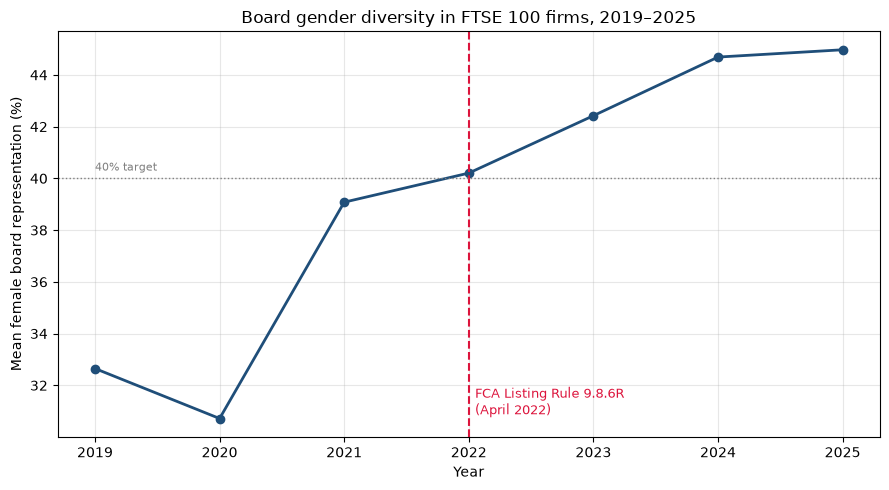

      mean   std  count  mean_pct
Year                             
2019  0.33  0.08     60     32.65
2020  0.31  0.09     57     30.72
2021  0.39  0.07     55     39.08
2022  0.40  0.07     63     40.20
2023  0.42  0.08     65     42.42
2024  0.45  0.09     66     44.69
2025  0.45  0.10     67     44.97


In [19]:
import matplotlib.pyplot as plt

yearly = p.groupby("Year")["GenderDiv"].agg(["mean","std","count"])
yearly["mean_pct"] = yearly["mean"] * 100

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(yearly.index, yearly["mean_pct"], marker="o", linewidth=2, color="#1f4e79")
ax.axvline(2022, color="crimson", linestyle="--", linewidth=1.5)
ax.text(2022.05, yearly["mean_pct"].min(), "FCA Listing Rule 9.8.6R\n(April 2022)",
        color="crimson", fontsize=9, va="bottom")
ax.axhline(40, color="grey", linestyle=":", linewidth=1)
ax.text(2019, 40.3, "40% target", fontsize=8, color="grey")
ax.set_xlabel("Year")
ax.set_ylabel("Mean female board representation (%)")
ax.set_title("Board gender diversity in FTSE 100 firms, 2019–2025")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/figures/fig1_diversity_trend.png", dpi=300)
plt.show()

print(yearly.round(2).to_string())

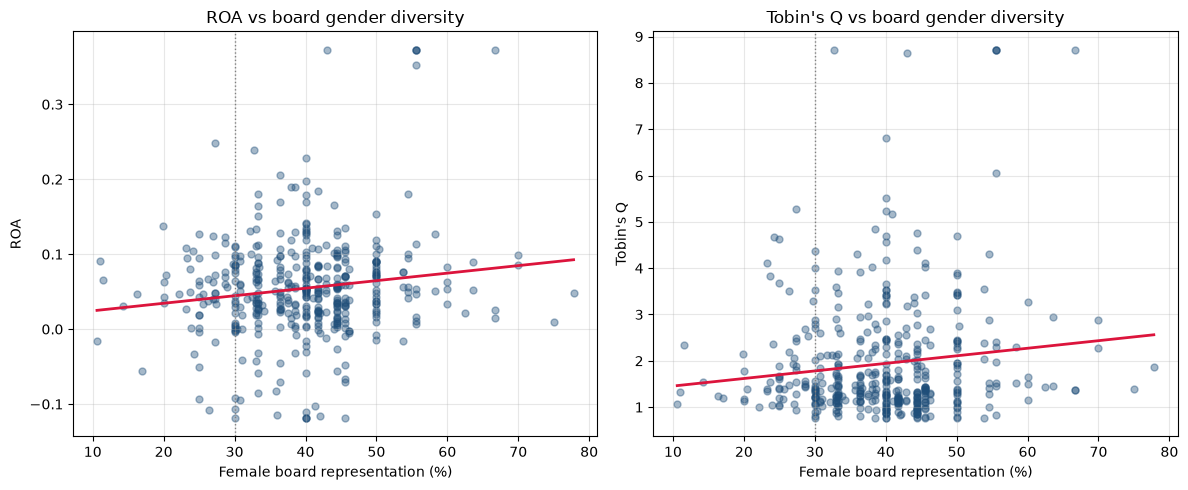

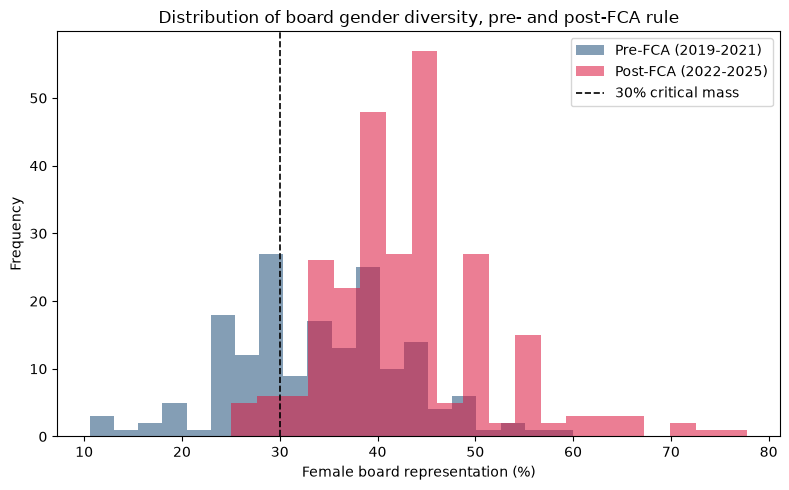

      below  at_or_above
Year                    
2019     17           43
2020     26           31
2021      3           52
2022      2           61
2023      3           62
2024      2           64
2025      1           66


In [20]:
import matplotlib.pyplot as plt

# Figure 2: scatter with fit
fig, axes = plt.subplots(1, 2, figsize=(12,5))
for ax, dv, label in zip(axes, ["ROA","TobinQ"], ["ROA","Tobin's Q"]):
    ax.scatter(p["GenderDiv"]*100, p[dv], alpha=0.4, s=25, color="#1f4e79")
    z = np.polyfit(p["GenderDiv"]*100, p[dv], 1)
    xs = np.linspace(p["GenderDiv"].min()*100, p["GenderDiv"].max()*100, 100)
    ax.plot(xs, np.poly1d(z)(xs), color="crimson", linewidth=2)
    ax.axvline(30, color="grey", linestyle=":", linewidth=1)
    ax.set_xlabel("Female board representation (%)")
    ax.set_ylabel(label)
    ax.set_title(f"{label} vs board gender diversity")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/figures/fig2_scatter.png", dpi=300)
plt.show()

# Figure 3: pre vs post FCA distributions
fig, ax = plt.subplots(figsize=(8,5))
for period, lbl, col in [(0,"Pre-FCA (2019-2021)","#1f4e79"), (1,"Post-FCA (2022-2025)","crimson")]:
    ax.hist(p[p["FCA_Post"]==period]["GenderDiv"]*100, bins=20, alpha=0.55, label=lbl, color=col)
ax.axvline(30, color="black", linestyle="--", linewidth=1.2, label="30% critical mass")
ax.set_xlabel("Female board representation (%)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of board gender diversity, pre- and post-FCA rule")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/figures/fig3_distributions.png", dpi=300)
plt.show()

# Critical mass counts by year — matters for H3
print(p.groupby("Year")["CriticalMass"].agg(below=lambda x: (x==0).sum(), at_or_above=lambda x: (x==1).sum()).to_string())

In [21]:
p["CriticalMass40"] = (p["GenderDiv"] >= 0.40).astype(int)

print("30% threshold:")
print(p.groupby("Year")["CriticalMass"].agg(below=lambda x:(x==0).sum(), above=lambda x:(x==1).sum()).to_string())
print("\n40% threshold:")
print(p.groupby("Year")["CriticalMass40"].agg(below=lambda x:(x==0).sum(), above=lambda x:(x==1).sum()).to_string())

p.to_csv("data/processed/analysis_panel.csv", index=False)

30% threshold:
      below  above
Year              
2019     17     43
2020     26     31
2021      3     52
2022      2     61
2023      3     62
2024      2     64
2025      1     66

40% threshold:
      below  above
Year              
2019     44     16
2020     48      9
2021     29     26
2022     28     35
2023     16     49
2024     12     54
2025     16     51


In [22]:
ax.axvline(40, color="darkgreen", linestyle="--", linewidth=1.2, label="40% FCA target")

In [23]:
top = p.nlargest(10, "TobinQ")[["Company","Year","TobinQ","GenderDiv"]]
print(top.to_string())

                                                 Company  Year    TobinQ  GenderDiv
81                                 Auto Trader Group Plc  2024  8.714652      0.667
147                                Auto Trader Group Plc  2023  8.714652      0.556
209                                Auto Trader Group Plc  2022  8.714652      0.556
275                                Auto Trader Group Plc  2021  8.714652      0.556
318                                Auto Trader Group Plc  2020  8.714652      0.327
387                                Auto Trader Group Plc  2019  8.646516      0.430
279                         Spirax-Sarco Engineering Plc  2021  6.799032      0.400
13                                 Auto Trader Group Plc  2025  6.044957      0.556
34                     InterContinental Hotels Group Plc  2025  5.504988      0.400
321  Spirax-Sarco Engineering Plc Industrial Engineering  2020  5.273966      0.273


In [24]:
!pip install linearmodels

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 56.0 MB/s  0:00:00

   -------------------- ------------------- 2/4 [formulaic]
   -------------------- ------------------- 2/4 [formulaic]
   ------------------------------ --------- 3/4 [linearmodels]
   ------------------------------ --------- 3/4 [linearmodels]
   ------------------------------ --------- 3/4 [linearmodels]
   ------------------------------ --------- 3/4 [linearmodels]
   ------------------------------ --------- 3/4 [linearmodels]
   ---------------------------------------- 4/4 [linearmodels]



In [25]:
import pandas as pd
import numpy as np
from linearmodels.panel import PanelOLS

p = pd.read_csv("data/processed/analysis_panel.csv")
p["CriticalMass40"] = (p["GenderDiv"] >= 0.40).astype(int)
p["GenderDiv_x_Post"] = p["GenderDiv"] * p["FCA_Post"]
p["GenderDivSq"] = p["GenderDiv"] ** 2

df = p.set_index(["CompanyKey", "Year"])
controls = ["FirmSize", "Leverage", "FirmAge"]
print("Ready:", df.shape)

Ready: (433, 26)


In [29]:
controls = ["FirmSize", "Leverage"]

for dv in ["ROA", "TobinQ"]:
    m = PanelOLS(df[dv], df[["GenderDiv"] + controls],
                 entity_effects=True, time_effects=True, drop_absorbed=True)
    r = m.fit(cov_type="clustered", cluster_entity=True)
    print(f"\n===== MODEL 1 (no FirmAge): {dv} =====")
    print(r.summary.tables[1])
    print(f"Within R²: {r.rsquared_within:.4f} | N: {r.nobs} | Entities: {r.entity_info.total}")


===== MODEL 1 (no FirmAge): ROA =====
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
GenderDiv      0.0287     0.0513     0.5598     0.5760     -0.0722      0.1296
FirmSize       0.0437     0.0270     1.6165     0.1069     -0.0095      0.0969
Leverage      -0.1481     0.0844    -1.7534     0.0804     -0.3142      0.0180
Within R²: 0.0929 | N: 433 | Entities: 74.0

===== MODEL 1 (no FirmAge): TobinQ =====
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
GenderDiv      0.4193     0.4529     0.9259     0.3551     -0.4714      1.3101
FirmSize       0.0231     0.4073     0.0568     0.9547     -0.7779      0.8242
Levera

In [30]:
for dv in ["ROA", "TobinQ"]:
    m = PanelOLS(df[dv], df[["GenderDiv", "GenderDiv_x_Post"] + controls],
                 entity_effects=True, time_effects=True, drop_absorbed=True)
    r = m.fit(cov_type="clustered", cluster_entity=True)
    print(f"\n{'='*20} MODEL 2: {dv} {'='*20}")
    print(r.summary.tables[1])
    print(f"Within R²: {r.rsquared_within:.4f} | N: {r.nobs}")


==================== MODEL 2: ROA ====================
                                Parameter Estimates                                 
                  Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------
GenderDiv            0.0052     0.0531     0.0979     0.9221     -0.0992      0.1096
GenderDiv_x_Post     0.0421     0.0520     0.8085     0.4193     -0.0603      0.1444
FirmSize             0.0439     0.0270     1.6254     0.1050     -0.0092      0.0969
Leverage            -0.1468     0.0851    -1.7247     0.0855     -0.3143      0.0206
Within R²: 0.0315 | N: 433

==================== MODEL 2: TobinQ ====================
                                Parameter Estimates                                 
                  Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------
GenderDi

In [31]:
for dv in ["ROA", "TobinQ"]:
    # threshold specification
    m = PanelOLS(df[dv], df[["CriticalMass40"] + controls],
                 entity_effects=True, time_effects=True, drop_absorbed=True)
    r = m.fit(cov_type="clustered", cluster_entity=True)
    print(f"\n===== MODEL 3a (40% threshold): {dv} =====")
    print(r.summary.tables[1])

    # quadratic specification
    m2 = PanelOLS(df[dv], df[["GenderDiv", "GenderDivSq"] + controls],
                  entity_effects=True, time_effects=True, drop_absorbed=True)
    r2 = m2.fit(cov_type="clustered", cluster_entity=True)
    print(f"\n===== MODEL 3b (quadratic): {dv} =====")
    print(r2.summary.tables[1])


===== MODEL 3a (40% threshold): ROA =====
                               Parameter Estimates                                
                Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------
CriticalMass40    -0.0033     0.0078    -0.4295     0.6678     -0.0186      0.0119
FirmSize           0.0439     0.0269     1.6334     0.1033     -0.0090      0.0967
Leverage          -0.1462     0.0843    -1.7348     0.0837     -0.3119      0.0195

===== MODEL 3b (quadratic): ROA =====
                              Parameter Estimates                              
             Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------
GenderDiv      -0.0498     0.1398    -0.3563     0.7218     -0.3248      0.2252
GenderDivSq     0.0975     0.1470     0.6633     0.5076     -0.1917      0.3867
FirmSize        0.04

In [32]:
print(p[["Company","IncorpYear","FirmAge"]].drop_duplicates("Company").sort_values("IncorpYear").head(10).to_string())

                         Company  IncorpYear  FirmAge
5                     Diageo Plc      1886.0    139.0
316         Diageo Plc Beverages      1886.0    134.0
218          Johnson Matthey Plc      1891.0    131.0
11                     Halma Plc      1894.0    131.0
37                  Unilever Plc      1894.0    131.0
329  Unilever Plc Personal Goods      1894.0    126.0
57                Weir Group Plc      1895.0    130.0
7                    Pearson Plc      1897.0    128.0
390                     Relx Plc      1902.0    117.0
16                      RELX Plc      1902.0    123.0


In [33]:
import pandas as pd
from linearmodels.panel import PanelOLS

controls = ["FirmSize", "Leverage"]
specs = {
    "M1_baseline": ["GenderDiv"],
    "M2_interaction": ["GenderDiv", "GenderDiv_x_Post"],
    "M3a_threshold40": ["CriticalMass40"],
    "M3b_quadratic": ["GenderDiv", "GenderDivSq"],
}

rows = []
for dv in ["ROA", "TobinQ"]:
    for name, xs in specs.items():
        r = PanelOLS(df[dv], df[xs + controls], entity_effects=True,
                     time_effects=True, drop_absorbed=True).fit(
                     cov_type="clustered", cluster_entity=True)
        for v in xs + controls:
            rows.append({"DV": dv, "Model": name, "Variable": v,
                         "Coef": round(r.params[v], 4),
                         "SE": round(r.std_errors[v], 4),
                         "t": round(r.tstats[v], 3),
                         "p": round(r.pvalues[v], 4),
                         "WithinR2": round(r.rsquared_within, 4),
                         "N": int(r.nobs)})

results = pd.DataFrame(rows)
results.to_csv("outputs/tables/regression_results.csv", index=False)
print(results.to_string(index=False))

    DV           Model         Variable    Coef     SE      t      p  WithinR2   N
   ROA     M1_baseline        GenderDiv  0.0287 0.0513  0.560 0.5760    0.0929 433
   ROA     M1_baseline         FirmSize  0.0437 0.0270  1.616 0.1069    0.0929 433
   ROA     M1_baseline         Leverage -0.1481 0.0844 -1.753 0.0804    0.0929 433
   ROA  M2_interaction        GenderDiv  0.0052 0.0531  0.098 0.9221    0.0315 433
   ROA  M2_interaction GenderDiv_x_Post  0.0421 0.0520  0.809 0.4193    0.0315 433
   ROA  M2_interaction         FirmSize  0.0439 0.0270  1.625 0.1050    0.0315 433
   ROA  M2_interaction         Leverage -0.1468 0.0851 -1.725 0.0855    0.0315 433
   ROA M3a_threshold40   CriticalMass40 -0.0033 0.0078 -0.430 0.6678    0.0934 433
   ROA M3a_threshold40         FirmSize  0.0439 0.0269  1.633 0.1033    0.0934 433
   ROA M3a_threshold40         Leverage -0.1462 0.0843 -1.735 0.0837    0.0934 433
   ROA   M3b_quadratic        GenderDiv -0.0498 0.1398 -0.356 0.7218    0.0926 433
   R

In [34]:
# 1. Blau index instead of proportion
for dv in ["ROA", "TobinQ"]:
    r = PanelOLS(df[dv], df[["Blau"] + controls], entity_effects=True,
                 time_effects=True, drop_absorbed=True).fit(cov_type="clustered", cluster_entity=True)
    print(f"\nBlau — {dv}: coef={r.params['Blau']:.4f}, p={r.pvalues['Blau']:.4f}")

# 2. Excluding Auto Trader (the Tobin's Q outlier)
df_noAT = df[~df.index.get_level_values(0).str.contains("AUTO TRADER", na=False)]
r = PanelOLS(df_noAT["TobinQ"], df_noAT[["CriticalMass40"] + controls], entity_effects=True,
             time_effects=True, drop_absorbed=True).fit(cov_type="clustered", cluster_entity=True)
print(f"\nCriticalMass40 on TobinQ excl. Auto Trader: coef={r.params['CriticalMass40']:.4f}, p={r.pvalues['CriticalMass40']:.4f}")


Blau — ROA: coef=0.0033, p=0.9652

Blau — TobinQ: coef=0.8707, p=0.1467

CriticalMass40 on TobinQ excl. Auto Trader: coef=0.1411, p=0.0368


In [35]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



In [36]:
import pandas as pd, numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
import shap
import matplotlib.pyplot as plt

p = pd.read_csv("data/processed/analysis_panel.csv")
p["CriticalMass40"] = (p["GenderDiv"] >= 0.40).astype(int)

features = ["GenderDiv", "FirmSize", "Leverage", "FCA_Post", "CriticalMass40"]
if "BoardSize" in p.columns and p["BoardSize"].notna().sum() > 400:
    features.append("BoardSize")

for dv in ["ROA", "TobinQ"]:
    d = p.dropna(subset=features + [dv])
    X, y = d[features], d[dv]
    
    cv = cross_val_score(RandomForestRegressor(n_estimators=500, random_state=42),
                         X, y, cv=5, scoring="r2")
    
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
    rf = RandomForestRegressor(n_estimators=500, random_state=42).fit(Xtr, ytr)
    
    print(f"\n===== {dv} =====")
    print(f"5-fold CV R²: {cv.mean():.4f} (SD {cv.std():.4f})")
    print(f"Test R²: {rf.score(Xte, yte):.4f}")
    print(pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False).round(4).to_string())
    
    explainer = shap.TreeExplainer(rf)
    sv = explainer.shap_values(Xte)
    
    shap.summary_plot(sv, Xte, show=False)
    plt.title(f"SHAP feature importance — {dv}")
    plt.tight_layout()
    plt.savefig(f"outputs/figures/shap_summary_{dv}.png", dpi=300, bbox_inches="tight")
    plt.close()
    
    shap.dependence_plot("GenderDiv", sv, Xte, show=False)
    plt.title(f"SHAP dependence: board gender diversity — {dv}")
    plt.tight_layout()
    plt.savefig(f"outputs/figures/shap_dependence_{dv}.png", dpi=300, bbox_inches="tight")
    plt.close()
    
    print("Figures saved.")


===== ROA =====
5-fold CV R²: 0.2478 (SD 0.1631)
Test R²: 0.2433
Leverage          0.4850
FirmSize          0.3526
GenderDiv         0.1332
FCA_Post          0.0191
CriticalMass40    0.0101
Figures saved.

===== TobinQ =====
5-fold CV R²: 0.6549 (SD 0.1343)
Test R²: 0.5015
FirmSize          0.5305
Leverage          0.3730
GenderDiv         0.0721
FCA_Post          0.0188
CriticalMass40    0.0055
Figures saved.
